# Author Writing Style Prediction Bot

## Objective

The objective of this project is to develop a machine learning bot that predicts the author of a text passage based on writing style.

The project will use public-domain books from Project Gutenberg. The books will be divided into smaller text passages to create a dataset containing at least 10,000 records.

Apache Spark and PySpark will be used for data processing and machine learning.

In [24]:
import pyspark
print("PySpark version:", pyspark.__version__)

PySpark version: 4.0.4


In [25]:
import os
from pyspark.sql import SparkSession

# Use the Java available in the fresh Colab runtime
java_path = os.popen("readlink -f $(which java)").read().strip()
os.environ["JAVA_HOME"] = os.path.dirname(os.path.dirname(java_path))

print("JAVA_HOME:", os.environ["JAVA_HOME"])

spark = (
    SparkSession.builder
    .appName("AuthorWritingStyleBot")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

print("Spark version:", spark.version)
print("Spark session created successfully.")

JAVA_HOME: /usr/lib/jvm/java-21-openjdk-amd64
Spark version: 4.0.4
Spark session created successfully.


In [26]:
!pip install -q pandas requests

## 3. Data Collection

The dataset will be created from public-domain books available through Project Gutenberg.

Rather than downloading a large pre-existing corpus, selected books will be retrieved individually.

Each book will later be divided into smaller passages. Each passage will inherit the author's name as its label.

This allows us to create a dataset of at least 10,000 records from a relatively small number of books.

In [27]:
import pandas as pd

catalog_url = "https://www.gutenberg.org/cache/epub/feeds/pg_catalog.csv"

catalog = pd.read_csv(catalog_url)

print("Catalogue shape:", catalog.shape)
catalog.head()

Catalogue shape: (79381, 9)


,Text#,Type,Issued,Title,Language,Authors,Subjects,LoCC,Bookshelves
0,1,Text,1971-12-01,The Declaration of Independence of the United ...,en,"Jefferson, Thomas, 1743-1826","United States -- History -- Revolution, 1775-1...",E201; JK,Politics; American Revolutionary War; United S...
1,2,Text,1972-12-01,The United States Bill of Rights\r\nThe Ten Or...,en,United States,Civil rights -- United States -- Sources; Unit...,JK; KF,Politics; American Revolutionary War; United S...
2,3,Text,1973-11-01,John F. Kennedy's Inaugural Address,en,"Kennedy, John F. (John Fitzgerald), 1917-1963",United States -- Foreign relations -- 1961-196...,E838,"Category: Essays, Letters & Speeches; Category..."
3,4,Text,1973-11-01,Lincoln's Gettysburg Address\r\nGiven November...,en,"Lincoln, Abraham, 1809-1865",Consecration of cemeteries -- Pennsylvania -- ...,E456,"US Civil War; Category: Essays, Letters & Spee..."
4,5,Text,1975-12-01,The United States Constitution,en,United States,United States -- Politics and government -- 17...,JK; KF,United States; Politics; American Revolutionar...


In [28]:
print(catalog.columns.tolist())

['Text#', 'Type', 'Issued', 'Title', 'Language', 'Authors', 'Subjects', 'LoCC', 'Bookshelves']


## 3.1 Select English Books

Filter the catalogue to English-language books.

In [29]:
# Keep English-language texts
english_books = catalog[
    catalog["Language"].astype(str).str.contains("en", na=False)
].copy()

print("English-language records:", len(english_books))

English-language records: 63045


In [30]:
# Count the number of books associated with each author
author_counts = (
    english_books["Authors"]
    .value_counts()
    .reset_index()
)

author_counts.columns = ["Author", "Book_Count"]

author_counts.head(20)

,Author,Book_Count
0,Various,2502
1,Anonymous,734
2,"Lytton, Edward Bulwer Lytton, Baron, 1803-1873",215
3,"Twain, Mark, 1835-1910",184
4,"Shakespeare, William, 1564-1616",168
5,"Various; Burnand, F. C. (Francis Cowley), 1836...",142
6,"Oliphant, Mrs. (Margaret), 1828-1897",137
7,"Various; Bell, George, 1814-1890 [Editor]",135
8,"Parker, Gilbert, 1862-1932",130
9,"Tuttle, W. C. (Wilbur C.), 1883-1969",128


## 3.2 Select Authors

Identify authors with at least 10 English-language books.

In [31]:
# Count books by author
author_counts = (
    english_books["Authors"]
    .value_counts()
    .reset_index()
)

author_counts.columns = ["Author", "Book_Count"]

# Keep authors with at least 10 books
suitable_authors = author_counts[
    author_counts["Book_Count"] >= 10
].copy()

print("Authors with at least 10 books:", len(suitable_authors))

suitable_authors.head(30)

Authors with at least 10 books: 726


,Author,Book_Count
0,Various,2502
1,Anonymous,734
2,"Lytton, Edward Bulwer Lytton, Baron, 1803-1873",215
3,"Twain, Mark, 1835-1910",184
4,"Shakespeare, William, 1564-1616",168
5,"Various; Burnand, F. C. (Francis Cowley), 1836...",142
6,"Oliphant, Mrs. (Margaret), 1828-1897",137
7,"Various; Bell, George, 1814-1890 [Editor]",135
8,"Parker, Gilbert, 1862-1932",130
9,"Tuttle, W. C. (Wilbur C.), 1883-1969",128


## 3.3 Filter Individual Authors

Remove generic author labels and keep established individual authors.

In [32]:
# Remove generic/multi-author entries
excluded = ["Various", "Anonymous"]

individual_authors = suitable_authors[
    ~suitable_authors["Author"].isin(excluded)
].copy()

print("Individual authors:", len(individual_authors))

individual_authors.head(30).to_string(index=False)

Individual authors: 724


'                                                                                                                                                                           Author  Book_Count\n                                                                                                                                   Lytton, Edward Bulwer Lytton, Baron, 1803-1873         215\n                                                                                                                                                           Twain, Mark, 1835-1910         184\n                                                                                                                                                  Shakespeare, William, 1564-1616         168\n                                                                                                                     Various; Burnand, F. C. (Francis Cowley), 1836-1917 [Editor]         142\n                                            

## 3.4 Clean Author Names

Keep records representing a single named author.


In [33]:
# Remove entries containing multiple authors or editors
single_authors = individual_authors[
    ~individual_authors["Author"].str.contains(
        ";|\[Editor\]|\[Illustrator\]|\[Translator\]",
        case=False,
        na=False
    )
].copy()

print("Single-author entries:", len(single_authors))

single_authors.head(30).to_string(index=False)

Single-author entries: 605


<>:4: SyntaxWarning: invalid escape sequence '\['
<>:4: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_1459/267940655.py:4: SyntaxWarning: invalid escape sequence '\['
  ";|\[Editor\]|\[Illustrator\]|\[Translator\]",


'                                        Author  Book_Count\nLytton, Edward Bulwer Lytton, Baron, 1803-1873         215\n                        Twain, Mark, 1835-1910         184\n               Shakespeare, William, 1564-1616         168\n          Oliphant, Mrs. (Margaret), 1828-1897         137\n                    Parker, Gilbert, 1862-1932         130\n          Tuttle, W. C. (Wilbur C.), 1883-1969         128\n                                       Unknown         119\n                Doyle, Arthur Conan, 1859-1930         118\n                   Dickens, Charles, 1812-1870         109\n                   Meredith, George, 1828-1909         108\n              Howells, William Dean, 1837-1920         105\n               Motley, John Lothrop, 1814-1877         100\n                Alger, Horatio, Jr., 1832-1899          96\n      Wells, H. G. (Herbert George), 1866-1946          96\n Ballantyne, R. M. (Robert Michael), 1825-1894          90\n      Kingston, William Henry Giles, 18

## 3.5 Select Authors

Select 10 established authors with enough available books.

In [34]:
# Remove Unknown and entries containing editors/other contributors
single_authors = individual_authors[
    (~individual_authors["Author"].isin(["Unknown"])) &
    (~individual_authors["Author"].str.contains(
        r";|\[Editor\]|\[Illustrator\]|\[Translator\]",
        case=False,
        na=False
    ))
].copy()

# Authors selected for the project
selected_authors = [
    "Twain, Mark, 1835-1910",
    "Shakespeare, William, 1564-1616",
    "Doyle, Arthur Conan, 1859-1930",
    "Dickens, Charles, 1812-1870",
    "Wells, H. G. (Herbert George), 1866-1946",
    "Alger, Horatio, Jr., 1832-1899",
    "Ballantyne, R. M. (Robert Michael), 1825-1894",
    "Howells, William Dean, 1837-1920",
    "Parker, Gilbert, 1862-1932",
    "Meredith, George, 1828-1909"
]

selected = single_authors[
    single_authors["Author"].isin(selected_authors)
].copy()

selected = selected.sort_values("Book_Count", ascending=False)

selected

,Author,Book_Count
3,"Twain, Mark, 1835-1910",184
4,"Shakespeare, William, 1564-1616",168
8,"Parker, Gilbert, 1862-1932",130
12,"Doyle, Arthur Conan, 1859-1930",118
13,"Dickens, Charles, 1812-1870",109
14,"Meredith, George, 1828-1909",108
15,"Howells, William Dean, 1837-1920",105
17,"Alger, Horatio, Jr., 1832-1899",96
18,"Wells, H. G. (Herbert George), 1866-1946",96
19,"Ballantyne, R. M. (Robert Michael), 1825-1894",90


## 4.1 Select Books

Select up to 20 books for each author.

In [35]:
# Get books belonging to the selected authors
selected_books = english_books[
    english_books["Authors"].isin(selected_authors)
].copy()

# Select up to 20 books per author
selected_books = (
    selected_books
    .groupby("Authors", group_keys=False)
    .head(20)
    .reset_index(drop=True)
)

print("Selected books:", len(selected_books))
print("Authors:", selected_books["Authors"].nunique())

selected_books[["Text#", "Title", "Authors", "Language"]].head(20)

Selected books: 200
Authors: 10


,Text#,Title,Authors,Language
0,35,The Time Machine,"Wells, H. G. (Herbert George), 1866-1946",en
1,36,The war of the worlds,"Wells, H. G. (Herbert George), 1866-1946",en
2,70,What Is Man? and Other Essays,"Twain, Mark, 1835-1910",en
3,74,"The Adventures of Tom Sawyer, Complete","Twain, Mark, 1835-1910",en
4,86,A Connecticut Yankee in King Arthur's Court,"Twain, Mark, 1835-1910",en
5,91,Tom Sawyer Abroad,"Twain, Mark, 1835-1910",en
6,93,"Tom Sawyer, Detective","Twain, Mark, 1835-1910",en
7,98,A Tale of Two Cities,"Dickens, Charles, 1812-1870",en
8,100,The Complete Works of William Shakespeare,"Shakespeare, William, 1564-1616",en
9,102,The Tragedy of Pudd'nhead Wilson,"Twain, Mark, 1835-1910",en


## 4.2 Check Book Distribution

Check how many books were selected for each author.

In [36]:
book_distribution = (
    selected_books["Authors"]
    .value_counts()
    .reset_index()
)

book_distribution.columns = ["Author", "Books"]

book_distribution

,Author,Books
0,"Wells, H. G. (Herbert George), 1866-1946",20
1,"Twain, Mark, 1835-1910",20
2,"Dickens, Charles, 1812-1870",20
3,"Shakespeare, William, 1564-1616",20
4,"Doyle, Arthur Conan, 1859-1930",20
5,"Howells, William Dean, 1837-1920",20
6,"Alger, Horatio, Jr., 1832-1899",20
7,"Ballantyne, R. M. (Robert Michael), 1825-1894",20
8,"Meredith, George, 1828-1909",20
9,"Parker, Gilbert, 1862-1932",20


## 5.1 Download Books

Download the selected Gutenberg books as plain text.

In [37]:
import requests
import time

# Create a folder for the books
import os

os.makedirs("gutenberg_books", exist_ok=True)

def download_book(book_id):
    """Download a Gutenberg book as plain text."""

    url = f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt"

    try:
        response = requests.get(url, timeout=30)

        if response.status_code == 200:
            return response.text

        return None

    except Exception:
        return None

## 5.2 Test Download

Test the download process with one book.

In [38]:
# Test with the first selected book
test_book = selected_books.iloc[0]

book_id = int(test_book["Text#"])
text = download_book(book_id)

print("Book ID:", book_id)
print("Title:", test_book["Title"])
print("Author:", test_book["Authors"])

if text:
    print("Download successful!")
    print("Characters:", len(text))
    print("\nFirst 500 characters:\n")
    print(text[:500])
else:
    print("Download failed.")

Book ID: 35
Title: The Time Machine
Author: Wells, H. G. (Herbert George), 1866-1946
Download successful!
Characters: 202504

First 500 characters:

The Project Gutenberg eBook of The Time Machine
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBo


## 6. Download Selected Books

Download the 200 selected books and store their text and metadata.

In [23]:
import requests
import time

books = []

for i, row in selected_books.iterrows():
    book_id = int(row["Text#"])
    author = row["Authors"]
    title = row["Title"]

    url = f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt"

    try:
        response = requests.get(url, timeout=30)

        if response.status_code == 200 and len(response.text) > 5000:
            books.append({
                "book_id": book_id,
                "title": title,
                "author": author,
                "text": response.text
            })

            print(f"{i+1}/200 | Success | {title[:50]}")
        else:
            print(f"{i+1}/200 | Failed | {title[:50]}")

    except Exception as e:
        print(f"{i+1}/200 | Error | {title[:50]}")

    # Small delay to avoid sending requests too quickly
    time.sleep(0.2)

print("\nFinished.")
print("Books successfully downloaded:", len(books))

1/200 | Success | The Time Machine
2/200 | Success | The war of the worlds
3/200 | Success | What Is Man? and Other Essays
4/200 | Success | The Adventures of Tom Sawyer, Complete
5/200 | Success | A Connecticut Yankee in King Arthur's Court
6/200 | Success | Tom Sawyer Abroad
7/200 | Success | Tom Sawyer, Detective
8/200 | Success | A Tale of Two Cities
9/200 | Success | The Complete Works of William Shakespeare
10/200 | Success | The Tragedy of Pudd'nhead Wilson
11/200 | Success | The Return of Sherlock Holmes
12/200 | Success | A Tramp Abroad
13/200 | Success | The Poison Belt
14/200 | Success | The Lost World
15/200 | Success | The $30,000 Bequest, and Other Stories
16/200 | Success | The Rise of Silas Lapham
17/200 | Success | The island of Doctor Moreau
18/200 | Success | The Return of Sherlock Holmes
19/200 | Success | A Study in Scarlet
20/200 | Success | Life on the Mississippi
21/200 | Success | The Stark Munro Letters
Being series of twelve le
22/200 | Success | Paul Prescot

In [39]:
print("Downloaded books:", len(books))

# Show a sample
books[0].keys()

Downloaded books: 200


dict_keys(['book_id', 'title', 'author', 'text'])

## 7. Clean Book Text

Remove Gutenberg metadata and unnecessary whitespace.

In [40]:
import re

def clean_gutenberg_text(text):
    # Remove Gutenberg header
    start = re.search(
        r"\*\*\* START OF (?:THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*",
        text,
        re.IGNORECASE | re.DOTALL
    )

    if start:
        text = text[start.end():]

    # Remove Gutenberg footer
    end = re.search(
        r"\*\*\* END OF (?:THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*",
        text,
        re.IGNORECASE | re.DOTALL
    )

    if end:
        text = text[:end.start()]

    # Remove excessive whitespace
    text = re.sub(r"\r\n", "\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"[ \t]+", " ", text)

    return text.strip()


# Clean all downloaded books
for book in books:
    book["clean_text"] = clean_gutenberg_text(book["text"])

print("Books cleaned:", len(books))

Books cleaned: 200


## 7.1 Check Cleaned Text

Compare the original and cleaned text.

In [41]:
book = books[0]

print("Title:", book["title"])
print("Author:", book["author"])

print("\nOriginal characters:", len(book["text"]))
print("Cleaned characters:", len(book["clean_text"]))

print("\nCleaned text sample:\n")
print(book["clean_text"][:1000])

Title: The Time Machine
Author: Wells, H. G. (Herbert George), 1866-1946

Original characters: 202504
Cleaned characters: 179629

Cleaned text sample:

The Time Machine

An Invention

by H. G. Wells

CONTENTS

 I Introduction
 II The Machine
 III The Time Traveller Returns
 IV Time Travelling
 V In the Golden Age
 VI The Sunset of Mankind
 VII A Sudden Shock
 VIII Explanation
 IX The Morlocks
 X When Night Came
 XI The Palace of Green Porcelain
 XII In the Darkness
 XIII The Trap of the White Sphinx
 XIV The Further Vision
 XV The Time Traveller’s Return
 XVI After the Story
 Epilogue

 I.
 Introduction

The Time Traveller (for so it will be convenient to speak of him)
was expounding a recondite matter to us. His grey eyes shone and
twinkled, and his usually pale face was flushed and animated. The
fire burnt brightly, and the soft radiance of the incandescent
lights in the lilies of silver caught the bubbles that flashed and
passed in our glasses. Our chairs, being his patents, embrace

## 8. Create Text Records

Split each book into 500-word passages.

In [42]:
# Create passages from each book

records = []

record_id = 1

for book in books:
    words = book["clean_text"].split()

    # Split into 500-word passages
    for start in range(0, len(words), 500):
        passage_words = words[start:start + 500]

        # Keep passages with at least 300 words
        if len(passage_words) >= 300:
            records.append({
                "record_id": record_id,
                "book_id": book["book_id"],
                "title": book["title"],
                "author": book["author"],
                "text": " ".join(passage_words)
            })

            record_id += 1

print("Total records:", len(records))

Total records: 26041


## 8.1 Check Dataset

Convert the records into a Spark DataFrame.

In [43]:
# Convert records to a Spark DataFrame

df = spark.createDataFrame(records)

print("Number of records:", df.count())
print("Number of columns:", len(df.columns))

df.show(5, truncate=100)

Number of records: 26041
Number of columns: 5
+----------------------------------------+-------+---------+----------------------------------------------------------------------------------------------------+----------------+
|                                  author|book_id|record_id|                                                                                                text|           title|
+----------------------------------------+-------+---------+----------------------------------------------------------------------------------------------------+----------------+
|Wells, H. G. (Herbert George), 1866-1946|     35|        1|The Time Machine An Invention by H. G. Wells CONTENTS I Introduction II The Machine III The Time ...|The Time Machine|
|Wells, H. G. (Herbert George), 1866-1946|     35|        2|making spasmodic efforts to relight his cigar over the lamp; “that . . . very clear indeed.” “Now...|The Time Machine|
|Wells, H. G. (Herbert George), 1866-1946|     35|        3

## 9. Check Author Distribution

The number of passages contributed by each author is examined to identify class imbalance caused by differences in book length.

In [44]:
# Count records per author

author_distribution = (
    df.groupBy("author")
      .count()
      .orderBy("count", ascending=False)
)

author_distribution.show(20, truncate=False)

+---------------------------------------------+-----+
|author                                       |count|
+---------------------------------------------+-----+
|Dickens, Charles, 1812-1870                  |5374 |
|Ballantyne, R. M. (Robert Michael), 1825-1894|3208 |
|Shakespeare, William, 1564-1616              |2752 |
|Wells, H. G. (Herbert George), 1866-1946     |2743 |
|Twain, Mark, 1835-1910                       |2580 |
|Doyle, Arthur Conan, 1859-1930               |2528 |
|Alger, Horatio, Jr., 1832-1899               |1862 |
|Meredith, George, 1828-1909                  |1857 |
|Parker, Gilbert, 1862-1932                   |1590 |
|Howells, William Dean, 1837-1920             |1547 |
+---------------------------------------------+-----+



## 9.1 Check Book Distribution

Check the number of books contributing to each author.

In [45]:
from pyspark.sql.functions import countDistinct

book_distribution = (
    df.groupBy("author")
      .agg(countDistinct("book_id").alias("book_count"))
      .orderBy("book_count", ascending=False)
)

book_distribution.show(20, truncate=False)

+---------------------------------------------+----------+
|author                                       |book_count|
+---------------------------------------------+----------+
|Twain, Mark, 1835-1910                       |20        |
|Meredith, George, 1828-1909                  |20        |
|Ballantyne, R. M. (Robert Michael), 1825-1894|20        |
|Parker, Gilbert, 1862-1932                   |20        |
|Alger, Horatio, Jr., 1832-1899               |20        |
|Howells, William Dean, 1837-1920             |20        |
|Doyle, Arthur Conan, 1859-1930               |20        |
|Dickens, Charles, 1812-1870                  |20        |
|Wells, H. G. (Herbert George), 1866-1946     |20        |
|Shakespeare, William, 1564-1616              |20        |
+---------------------------------------------+----------+



## 9.2 Check Passage Distribution

Calculate the number of text passages generated for each author.

In [46]:
from pyspark.sql import functions as F

passage_distribution = (
    df
    .groupBy("author")
    .agg(
        F.count("*").alias("passage_count")
    )
    .orderBy(
        F.desc("passage_count")
    )
)

passage_distribution.show(10, truncate=False)

+---------------------------------------------+-------------+
|author                                       |passage_count|
+---------------------------------------------+-------------+
|Dickens, Charles, 1812-1870                  |5374         |
|Ballantyne, R. M. (Robert Michael), 1825-1894|3208         |
|Shakespeare, William, 1564-1616              |2752         |
|Wells, H. G. (Herbert George), 1866-1946     |2743         |
|Twain, Mark, 1835-1910                       |2580         |
|Doyle, Arthur Conan, 1859-1930               |2528         |
|Alger, Horatio, Jr., 1832-1899               |1862         |
|Meredith, George, 1828-1909                  |1857         |
|Parker, Gilbert, 1862-1932                   |1590         |
|Howells, William Dean, 1837-1920             |1547         |
+---------------------------------------------+-------------+



### 9.2 Visualise Book Distribution

The number of books selected for each author is visualised to confirm that the dataset contains an equal number of books per author.

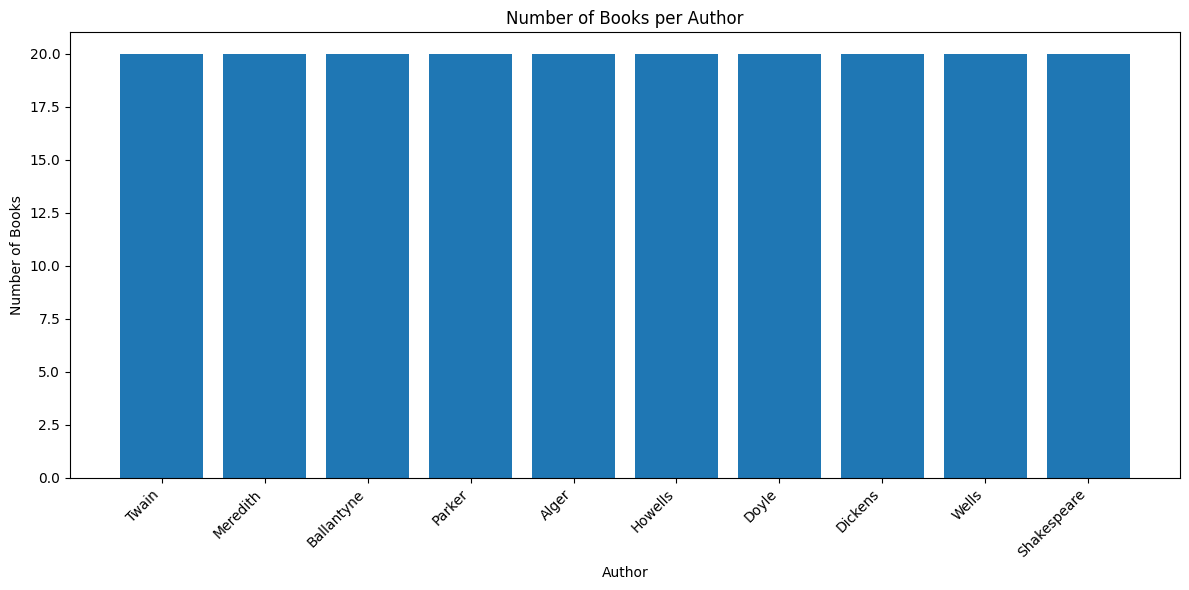

In [47]:
import matplotlib.pyplot as plt

# Convert the Spark result to Pandas
book_counts_pd = book_distribution.toPandas()

# Extract shorter author names
book_counts_pd["author_short"] = (
    book_counts_pd["author"]
    .str.split(",")
    .str[0]
)

# Plot
plt.figure(figsize=(12, 6))

plt.bar(
    book_counts_pd["author_short"],
    book_counts_pd["book_count"]
)

plt.title("Number of Books per Author")
plt.xlabel("Author")
plt.ylabel("Number of Books")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

# Save figure for the report
plt.savefig(
    "9_2_books_per_author.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.3 Analyse Passage Length

The distribution of passage lengths is examined to confirm consistency in the text records used for modelling.

In [48]:
from pyspark.sql import functions as F

passage_lengths = (
    df.withColumn(
        "word_count",
        F.size(F.split(F.col("text"), " "))
    )
    .select("word_count")
)

passage_lengths.describe().show()

+-------+-----------------+
|summary|       word_count|
+-------+-----------------+
|  count|            26041|
|   mean|499.7233209170155|
| stddev| 6.05518505264519|
|    min|              300|
|    max|              500|
+-------+-----------------+



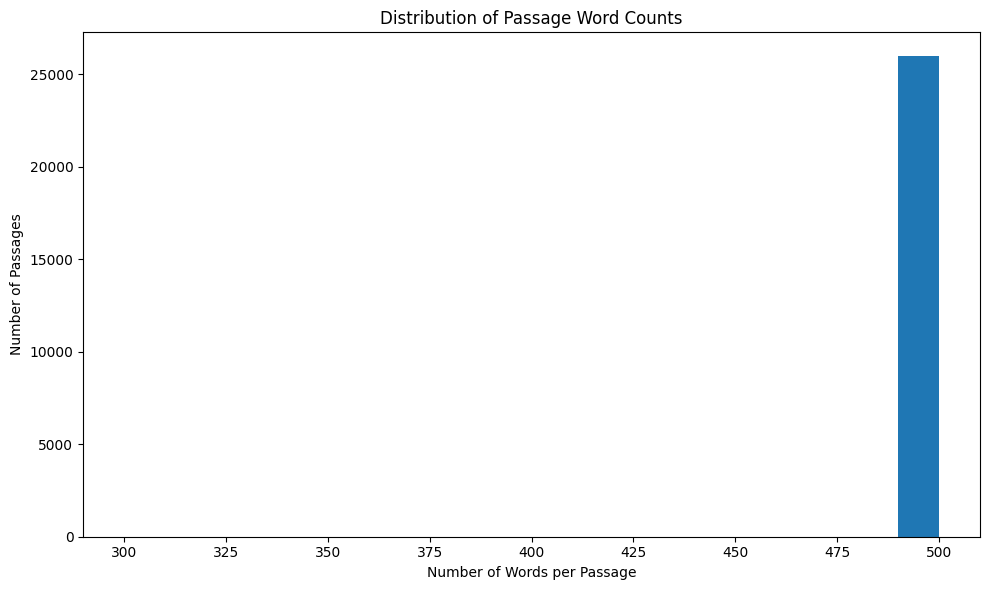

In [49]:
import matplotlib.pyplot as plt

# Convert word counts to Pandas
length_pd = passage_lengths.toPandas()

plt.figure(figsize=(10, 6))

plt.hist(
    length_pd["word_count"],
    bins=20
)

plt.title("Distribution of Passage Word Counts")
plt.xlabel("Number of Words per Passage")
plt.ylabel("Number of Passages")

plt.tight_layout()

plt.savefig(
    "9_4_passage_word_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.4 Analyse Book Length

The number of words in each book is examined to identify differences in book length across authors.

In [50]:
from pyspark.sql import functions as F

book_lengths = (
    df.groupBy("author", "book_id", "title")
      .agg(
          F.sum(
              F.size(F.split(F.col("text"), " "))
          ).alias("word_count")
      )
)

book_lengths.show(5, truncate=False)

+----------------------------------------+-------+------------------------------------------------+----------+
|author                                  |book_id|title                                           |word_count|
+----------------------------------------+-------+------------------------------------------------+----------+
|Wells, H. G. (Herbert George), 1866-1946|36     |The war of the worlds                           |60000     |
|Doyle, Arthur Conan, 1859-1930          |139    |The Lost World                                  |75500     |
|Alger, Horatio, Jr., 1832-1899          |530    |Driven from Home; Or, Carl Crawford's Experience|52000     |
|Dickens, Charles, 1812-1870             |564    |The Mystery of Edwin Drood                      |95500     |
|Dickens, Charles, 1812-1870             |644    |The Haunted Man and the Ghost's Bargain         |33500     |
+----------------------------------------+-------+------------------------------------------------+----------+
o

/tmp/ipykernel_1459/67750515.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


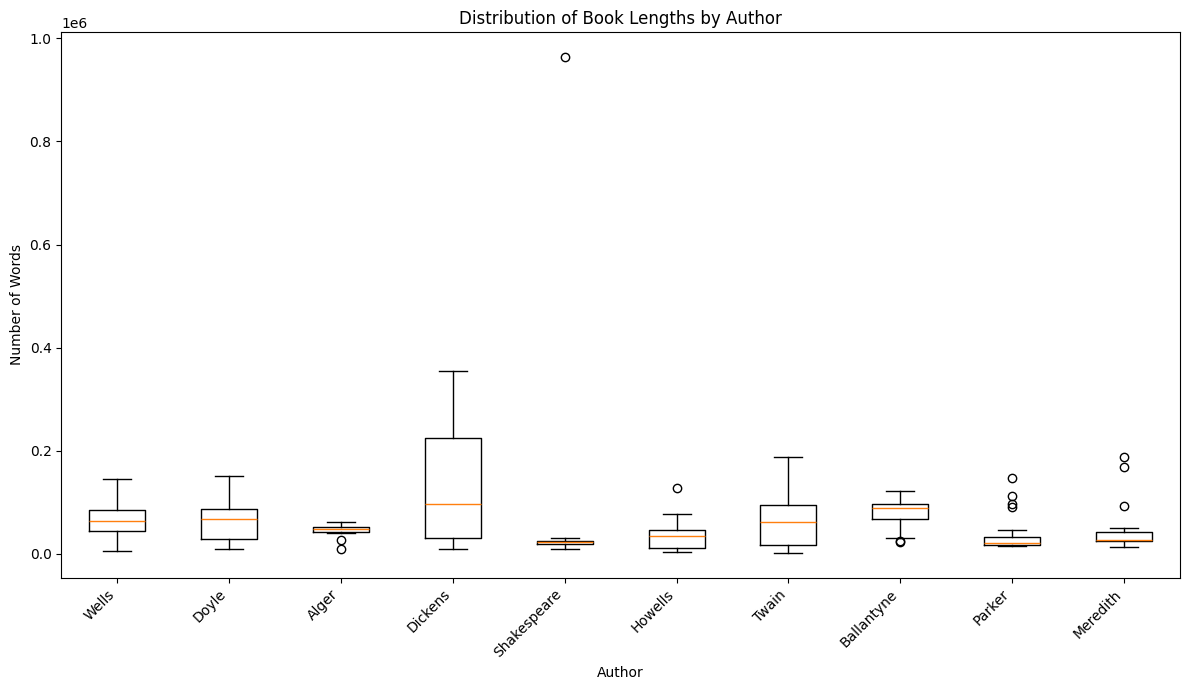

In [51]:
import matplotlib.pyplot as plt

book_lengths_pd = book_lengths.toPandas()

book_lengths_pd["author_short"] = (
    book_lengths_pd["author"]
    .str.split(",")
    .str[0]
)

plt.figure(figsize=(12, 7))

plt.boxplot(
    [
        book_lengths_pd[
            book_lengths_pd["author_short"] == author
        ]["word_count"]
        for author in book_lengths_pd["author_short"].unique()
    ],
    labels=book_lengths_pd["author_short"].unique()
)

plt.title("Distribution of Book Lengths by Author")
plt.xlabel("Author")
plt.ylabel("Number of Words")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    "9_5_book_length_by_author.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.5 Analyse Records per Book

The number of passages generated from each book is examined to identify variation in the contribution of individual books to the dataset.

In [52]:
from pyspark.sql import functions as F

records_per_book = (
    df.groupBy("author", "book_id", "title")
      .count()
      .withColumnRenamed("count", "record_count")
      .orderBy("record_count", ascending=False)
)

records_per_book.show(10, truncate=False)

+-------------------------------+-------+--------------------------------------------------------------------+------------+
|author                         |book_id|title                                                               |record_count|
+-------------------------------+-------+--------------------------------------------------------------------+------------+
|Shakespeare, William, 1564-1616|100    |The Complete Works of William Shakespeare                           |1927        |
|Dickens, Charles, 1812-1870    |821    |Dombey and Son                                                      |710         |
|Dickens, Charles, 1812-1870    |766    |David Copperfield                                                   |710         |
|Dickens, Charles, 1812-1870    |883    |Our Mutual Friend                                                   |650         |
|Dickens, Charles, 1812-1870    |580    |The Pickwick Papers                                                 |600         |
|Dickens

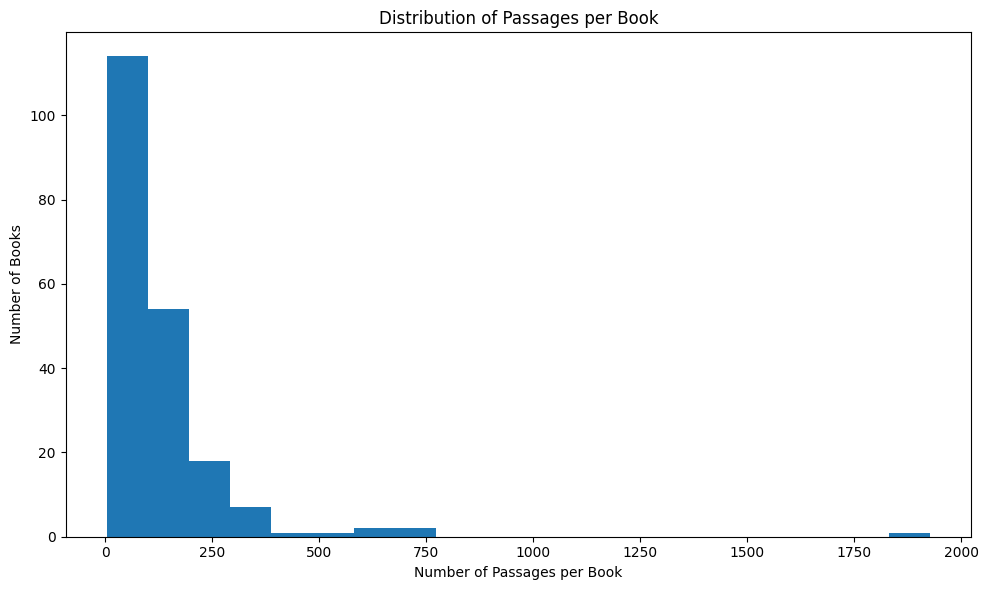

In [53]:
import matplotlib.pyplot as plt

records_per_book_pd = records_per_book.toPandas()

plt.figure(figsize=(10, 6))

plt.hist(
    records_per_book_pd["record_count"],
    bins=20
)

plt.title("Distribution of Passages per Book")
plt.xlabel("Number of Passages per Book")
plt.ylabel("Number of Books")

plt.tight_layout()

plt.savefig(
    "9_6_records_per_book.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.6 Sentence Length by Author

Sentence length is examined as a potential writing-style characteristic. Differences in average sentence length may help distinguish authors.

In [54]:
from pyspark.sql import functions as F

# Estimate sentence counts
sentence_data = (
    df.withColumn(
        "sentence_count",
        F.size(
            F.split(
                F.col("text"),
                r"[.!?]+"
            )
        )
    )
    .withColumn(
        "word_count",
        F.size(F.split(F.col("text"), " "))
    )
    .withColumn(
        "words_per_sentence",
        F.col("word_count") / F.col("sentence_count")
    )
)

# Average sentence length by author
sentence_length = (
    sentence_data
    .groupBy("author")
    .agg(
        F.avg("words_per_sentence").alias("avg_words_per_sentence")
    )
    .orderBy("avg_words_per_sentence", ascending=False)
)

sentence_length.show(20, truncate=False)

+---------------------------------------------+----------------------+
|author                                       |avg_words_per_sentence|
+---------------------------------------------+----------------------+
|Ballantyne, R. M. (Robert Michael), 1825-1894|21.015416170351447    |
|Twain, Mark, 1835-1910                       |20.270470869992764    |
|Howells, William Dean, 1837-1920             |20.035666790993925    |
|Dickens, Charles, 1812-1870                  |19.349306420177808    |
|Meredith, George, 1828-1909                  |17.742880913830273    |
|Wells, H. G. (Herbert George), 1866-1946     |16.967968367268583    |
|Parker, Gilbert, 1862-1932                   |16.65093614896059     |
|Doyle, Arthur Conan, 1859-1930               |16.592957751565265    |
|Shakespeare, William, 1564-1616              |12.26483956865561     |
|Alger, Horatio, Jr., 1832-1899               |10.884450857708018    |
+---------------------------------------------+----------------------+



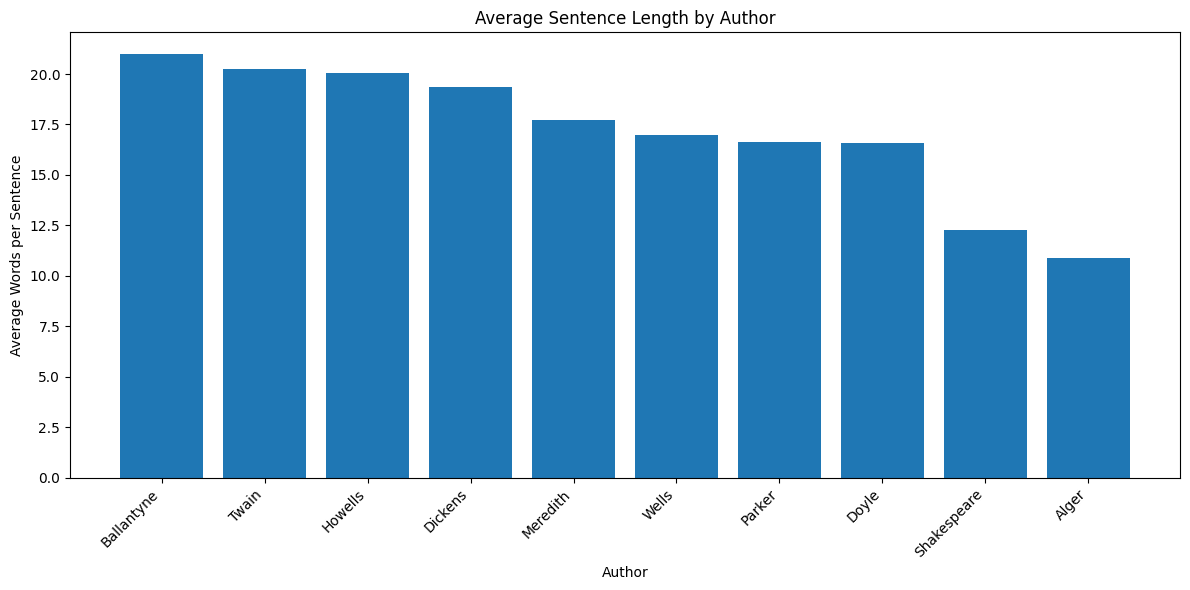

In [55]:
import matplotlib.pyplot as plt

sentence_pd = sentence_length.toPandas()

sentence_pd["author_short"] = (
    sentence_pd["author"]
    .str.split(",")
    .str[0]
)

plt.figure(figsize=(12, 6))

plt.bar(
    sentence_pd["author_short"],
    sentence_pd["avg_words_per_sentence"]
)

plt.title("Average Sentence Length by Author")
plt.xlabel("Author")
plt.ylabel("Average Words per Sentence")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "9_7_average_sentence_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.7 Vocabulary Size by Author

The number of unique words is examined as an indicator of vocabulary diversity across authors.

In [56]:
from pyspark.sql import functions as F

vocabulary = (
    df
    .select(
        "author",
        F.explode(
            F.split(
                F.lower(F.col("text")),
                r"\W+"
            )
        ).alias("word")
    )
    .filter(F.col("word") != "")
    .distinct()
    .groupBy("author")
    .count()
    .withColumnRenamed("count", "unique_words")
    .orderBy("unique_words", ascending=False)
)

vocabulary.show(20, truncate=False)

+---------------------------------------------+------------+
|author                                       |unique_words|
+---------------------------------------------+------------+
|Dickens, Charles, 1812-1870                  |35610       |
|Twain, Mark, 1835-1910                       |34780       |
|Shakespeare, William, 1564-1616              |34401       |
|Wells, H. G. (Herbert George), 1866-1946     |34279       |
|Ballantyne, R. M. (Robert Michael), 1825-1894|30383       |
|Doyle, Arthur Conan, 1859-1930               |28628       |
|Meredith, George, 1828-1909                  |26554       |
|Howells, William Dean, 1837-1920             |22802       |
|Parker, Gilbert, 1862-1932                   |17803       |
|Alger, Horatio, Jr., 1832-1899               |17740       |
+---------------------------------------------+------------+



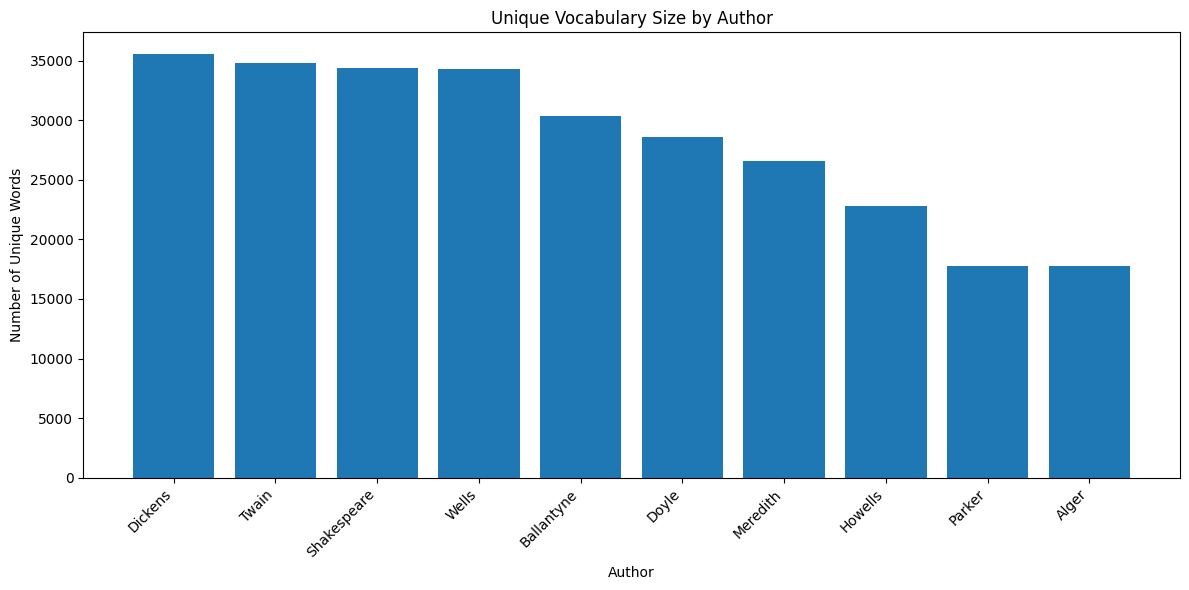

In [57]:
import matplotlib.pyplot as plt

vocabulary_pd = vocabulary.toPandas()

vocabulary_pd["author_short"] = (
    vocabulary_pd["author"]
    .str.split(",")
    .str[0]
)

plt.figure(figsize=(12, 6))

plt.bar(
    vocabulary_pd["author_short"],
    vocabulary_pd["unique_words"]
)

plt.title("Unique Vocabulary Size by Author")
plt.xlabel("Author")
plt.ylabel("Number of Unique Words")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "9_8_vocabulary_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.8 Most Frequent Words by Author

The most frequently occurring words are examined after removing common English stopwords. This provides an initial view of differences in word usage across authors.

In [58]:
from pyspark.sql import functions as F

# Split text into individual words
words = (
    df
    .select(
        "author",
        F.explode(
            F.split(
                F.lower(F.col("text")),
                r"\W+"
            )
        ).alias("word")
    )
    .filter(F.length("word") > 2)
)

# Common English stopwords
stopwords = {
    "the", "and", "that", "this", "with", "from", "have", "were",
    "they", "which", "their", "there", "would", "could", "should",
    "about", "what", "when", "where", "then", "them", "into",
    "your", "you", "for", "not", "but", "are", "was", "his",
    "her", "she", "him", "had", "has", "all", "one", "out",
    "can", "will", "more", "who", "been", "its", "our", "said"
}

# Remove stopwords
filtered_words = words.filter(
    ~F.col("word").isin(stopwords)
)

# Word frequency by author
word_frequency = (
    filtered_words
    .groupBy("author", "word")
    .count()
    .orderBy("author", F.desc("count"))
)

word_frequency.show(30, truncate=False)

+------------------------------+-------+-----+
|author                        |word   |count|
+------------------------------+-------+-----+
|Alger, Horatio, Jr., 1832-1899|don    |2956 |
|Alger, Horatio, Jr., 1832-1899|did    |2374 |
|Alger, Horatio, Jr., 1832-1899|boy    |2358 |
|Alger, Horatio, Jr., 1832-1899|asked  |2349 |
|Alger, Horatio, Jr., 1832-1899|know   |2292 |
|Alger, Horatio, Jr., 1832-1899|very   |2253 |
|Alger, Horatio, Jr., 1832-1899|yes    |2218 |
|Alger, Horatio, Jr., 1832-1899|well   |2210 |
|Alger, Horatio, Jr., 1832-1899|think  |2133 |
|Alger, Horatio, Jr., 1832-1899|good   |2103 |
|Alger, Horatio, Jr., 1832-1899|man    |2035 |
|Alger, Horatio, Jr., 1832-1899|money  |1968 |
|Alger, Horatio, Jr., 1832-1899|some   |1964 |
|Alger, Horatio, Jr., 1832-1899|much   |1956 |
|Alger, Horatio, Jr., 1832-1899|mrs    |1884 |
|Alger, Horatio, Jr., 1832-1899|see    |1883 |
|Alger, Horatio, Jr., 1832-1899|any    |1842 |
|Alger, Horatio, Jr., 1832-1899|time   |1801 |
|Alger, Horat

In [59]:
from pyspark.sql.window import Window
from pyspark.sql import functions as F

# Rank words within each author
word_window = Window.partitionBy("author").orderBy(F.desc("count"))

top_words = (
    word_frequency
    .withColumn("rank", F.row_number().over(word_window))
    .filter(F.col("rank") <= 10)
    .orderBy("author", "rank")
)

top_words.show(100, truncate=False)

+---------------------------------------------+-------+-----+----+
|author                                       |word   |count|rank|
+---------------------------------------------+-------+-----+----+
|Alger, Horatio, Jr., 1832-1899               |don    |2956 |1   |
|Alger, Horatio, Jr., 1832-1899               |did    |2374 |2   |
|Alger, Horatio, Jr., 1832-1899               |boy    |2358 |3   |
|Alger, Horatio, Jr., 1832-1899               |asked  |2349 |4   |
|Alger, Horatio, Jr., 1832-1899               |know   |2292 |5   |
|Alger, Horatio, Jr., 1832-1899               |very   |2253 |6   |
|Alger, Horatio, Jr., 1832-1899               |yes    |2218 |7   |
|Alger, Horatio, Jr., 1832-1899               |well   |2210 |8   |
|Alger, Horatio, Jr., 1832-1899               |think  |2133 |9   |
|Alger, Horatio, Jr., 1832-1899               |good   |2103 |10  |
|Ballantyne, R. M. (Robert Michael), 1825-1894|time   |3474 |1   |
|Ballantyne, R. M. (Robert Michael), 1825-1894|now    |3239 |2

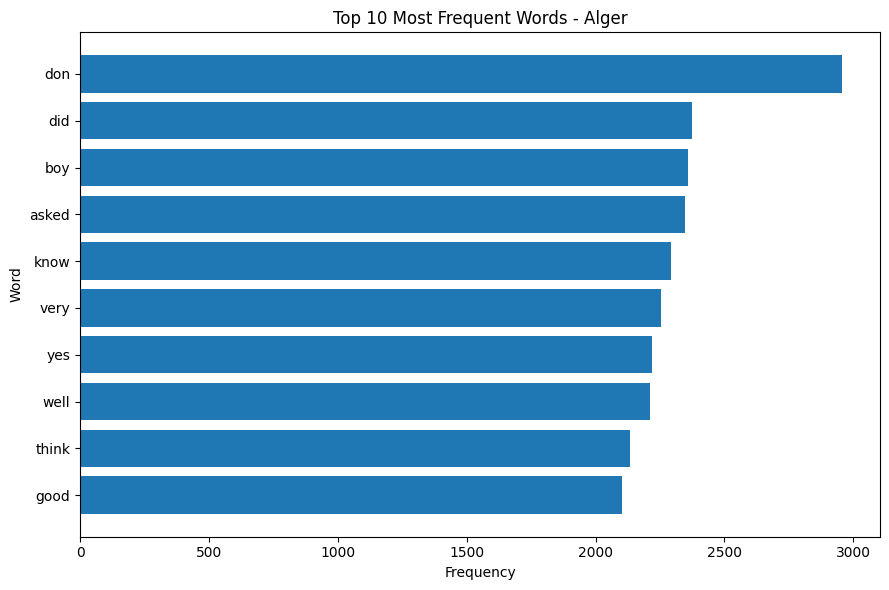

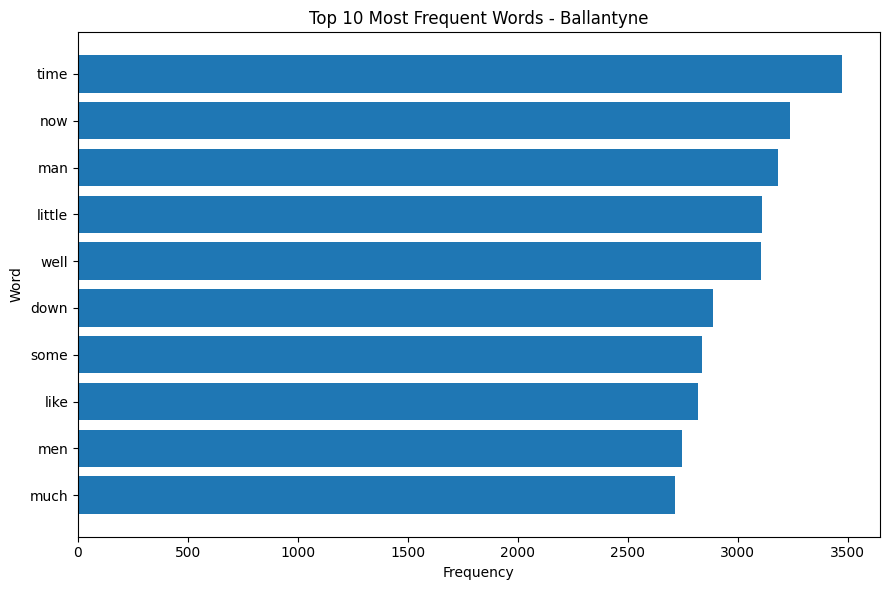

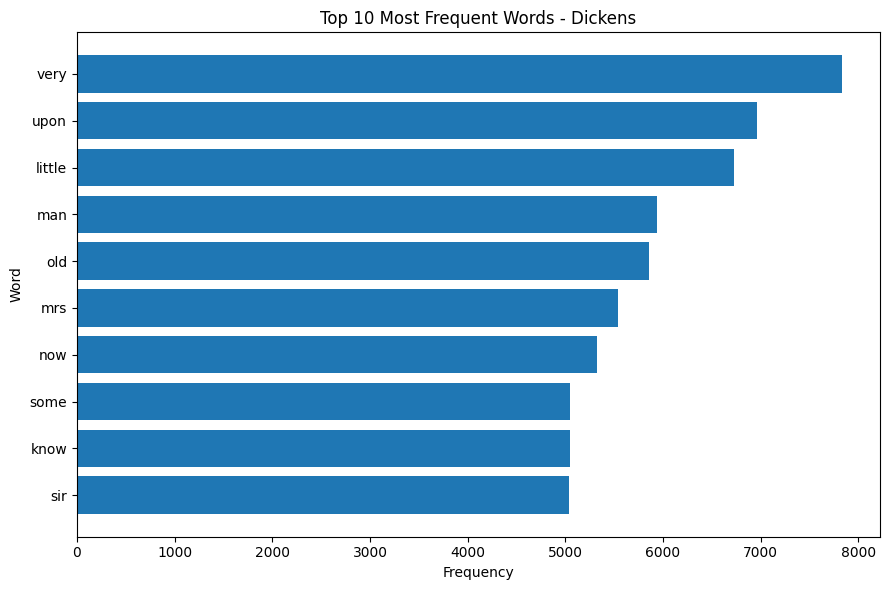

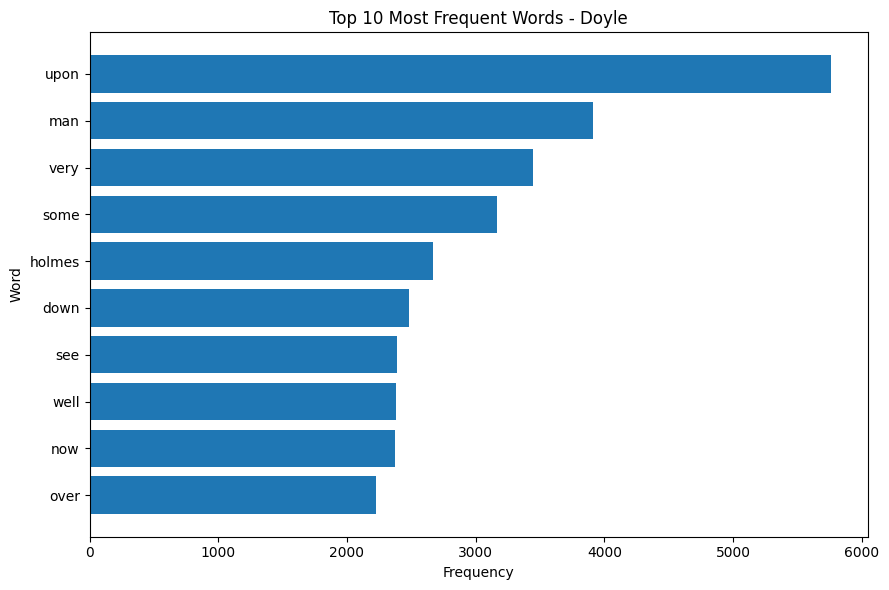

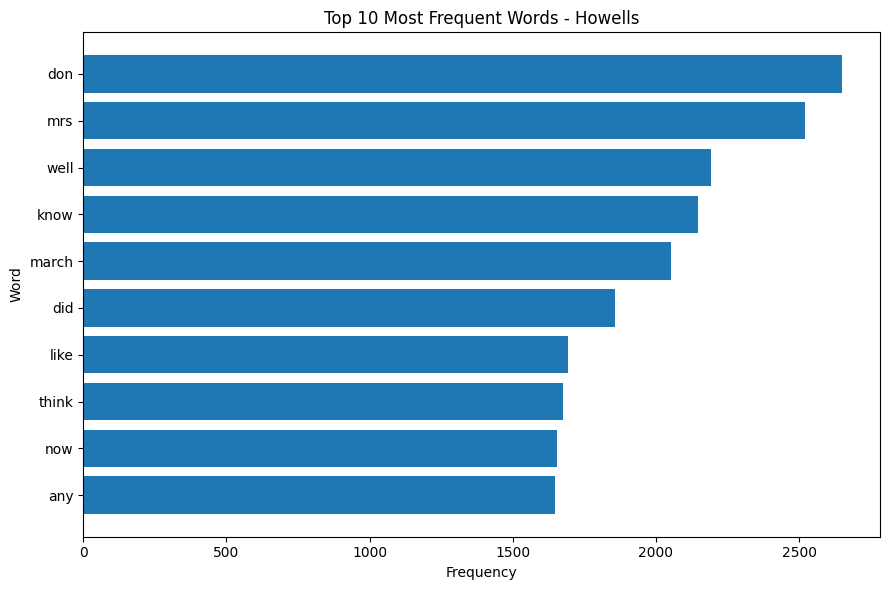

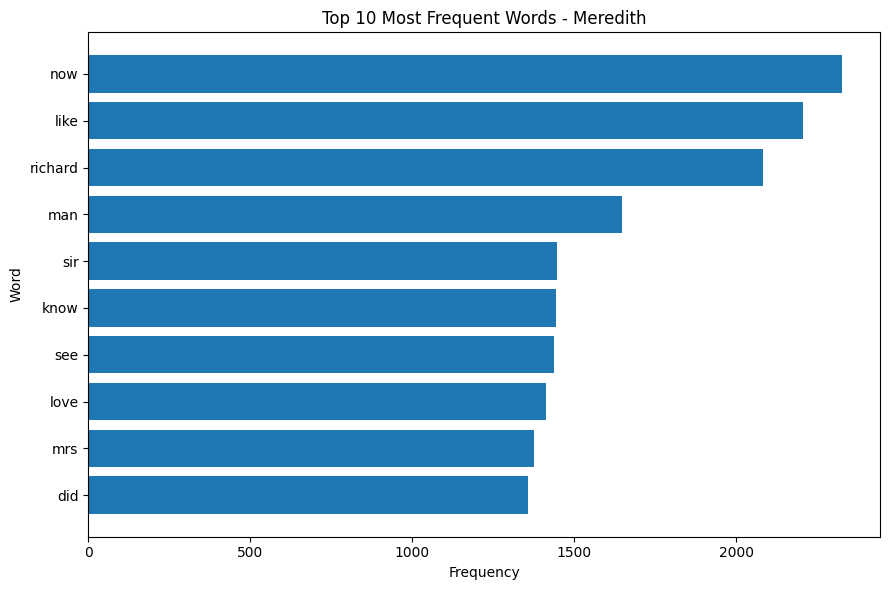

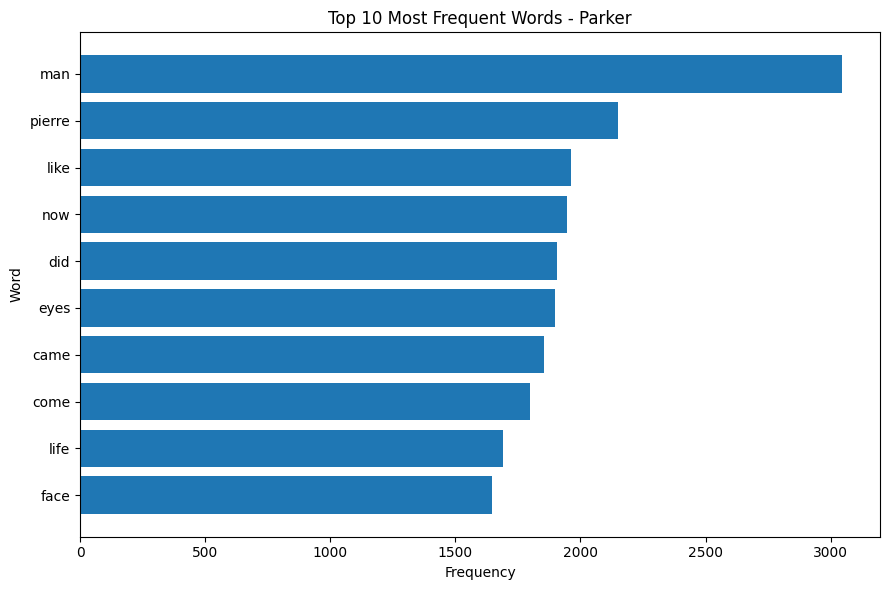

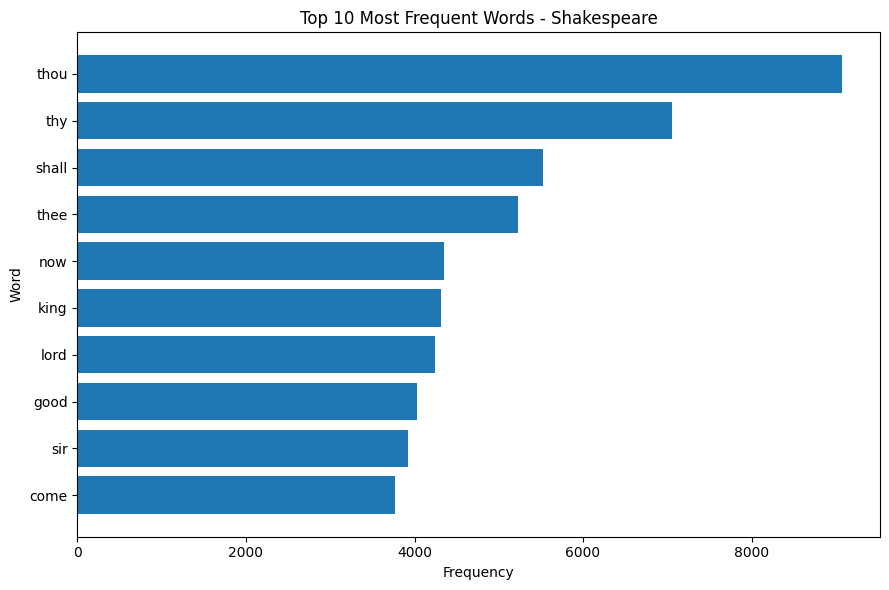

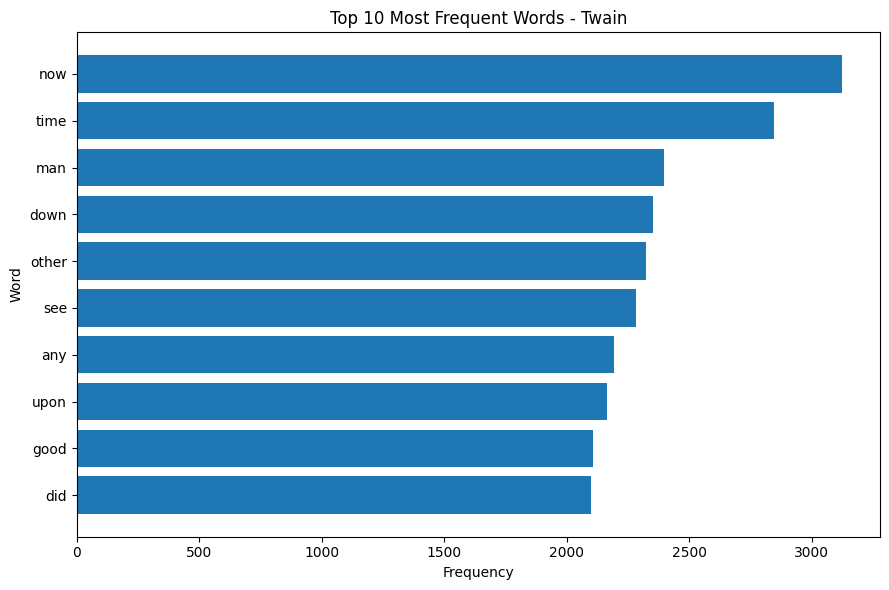

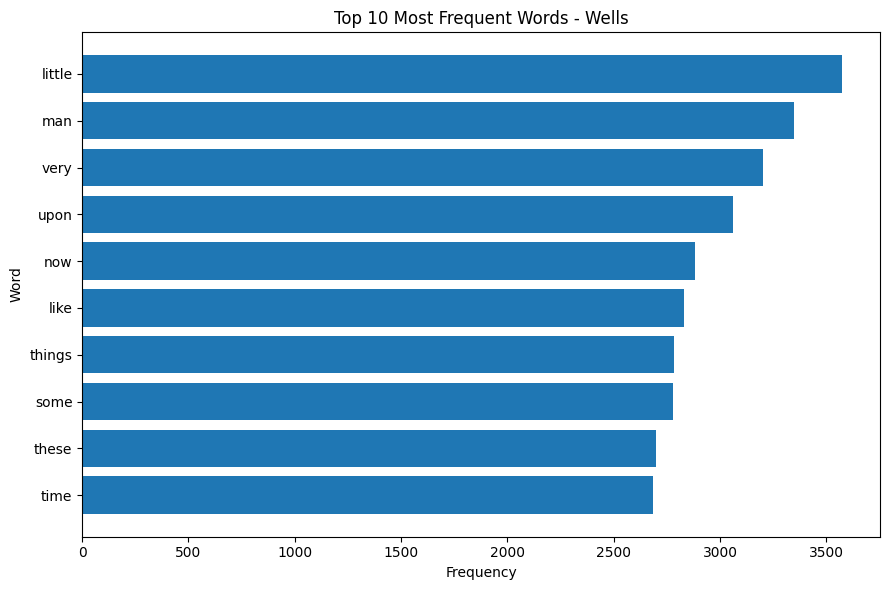

In [60]:
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas
top_words_pd = top_words.toPandas()

# Get authors
authors = top_words_pd["author"].unique()

# Create one chart per author
for author in authors:

    author_data = (
        top_words_pd[top_words_pd["author"] == author]
        .sort_values("count", ascending=True)
    )

    author_name = author.split(",")[0]

    plt.figure(figsize=(9, 6))

    plt.barh(
        author_data["word"],
        author_data["count"]
    )

    plt.title(f"Top 10 Most Frequent Words - {author_name}")
    plt.xlabel("Frequency")
    plt.ylabel("Word")

    plt.tight_layout()

    # Save each figure
    filename = f"9_10_top_words_{author_name.lower().replace(' ', '_')}.png"
    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### 9.10 Analyse Author-Specific Vocabulary

The average number of unique words per passage is calculated for each author. This provides an additional exploratory measure of vocabulary diversity across the selected authors.

In [61]:
from pyspark.sql import functions as F

vocabulary_per_passage = (
    df
    .withColumn(
        "words",
        F.split(F.lower(F.col("text")), r"\W+")
    )
    .withColumn(
        "unique_word_count",
        F.size(
            F.array_distinct(
                F.filter(
                    F.col("words"),
                    lambda x: x != ""
                )
            )
        )
    )
)

author_vocabulary = (
    vocabulary_per_passage
    .groupBy("author")
    .agg(
        F.avg("unique_word_count").alias("avg_unique_words_per_passage")
    )
    .orderBy(
        "avg_unique_words_per_passage",
        ascending=False
    )
)

author_vocabulary.show(20, truncate=False)

+---------------------------------------------+----------------------------+
|author                                       |avg_unique_words_per_passage|
+---------------------------------------------+----------------------------+
|Meredith, George, 1828-1909                  |268.4658050619278           |
|Ballantyne, R. M. (Robert Michael), 1825-1894|267.8444513715711           |
|Wells, H. G. (Herbert George), 1866-1946     |261.10280714546116          |
|Doyle, Arthur Conan, 1859-1930               |258.48180379746833          |
|Shakespeare, William, 1564-1616              |258.2674418604651           |
|Twain, Mark, 1835-1910                       |258.22829457364344          |
|Dickens, Charles, 1812-1870                  |256.4776702642352           |
|Howells, William Dean, 1837-1920             |250.0452488687783           |
|Parker, Gilbert, 1862-1932                   |248.4056603773585           |
|Alger, Horatio, Jr., 1832-1899               |243.50483351235232          |

### 9.11 Visualise Author-Specific Vocabulary

The average number of unique words per passage is visualised to compare vocabulary diversity across authors.

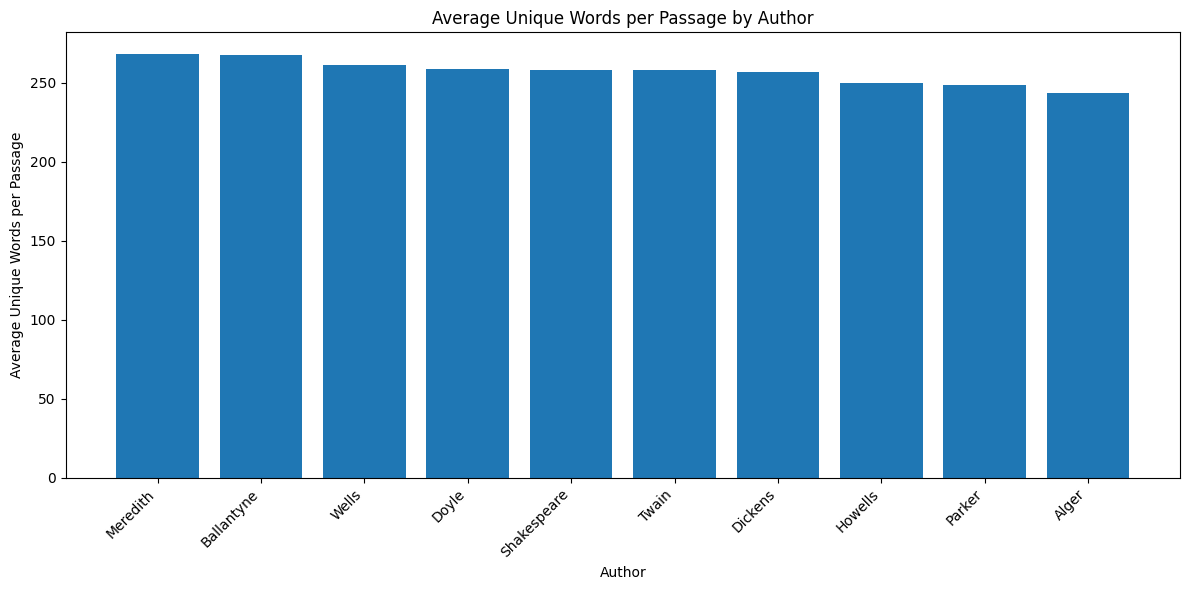

In [62]:
import matplotlib.pyplot as plt

vocabulary_pd = author_vocabulary.toPandas()

vocabulary_pd["author_short"] = (
    vocabulary_pd["author"]
    .str.split(",")
    .str[0]
)

plt.figure(figsize=(12, 6))

plt.bar(
    vocabulary_pd["author_short"],
    vocabulary_pd["avg_unique_words_per_passage"]
)

plt.title("Average Unique Words per Passage by Author")
plt.xlabel("Author")
plt.ylabel("Average Unique Words per Passage")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "9_11_average_unique_words.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.12 Analyse Character Count

The average number of characters per passage is calculated for each author. This provides an additional measure of passage length and text structure.

In [63]:
from pyspark.sql import functions as F

character_length = (
    df
    .withColumn(
        "character_count",
        F.length(F.col("text"))
    )
    .groupBy("author")
    .agg(
        F.avg("character_count").alias("avg_character_count")
    )
    .orderBy(
        "avg_character_count",
        ascending=False
    )
)

character_length.show(20, truncate=False)

+---------------------------------------------+-------------------+
|author                                       |avg_character_count|
+---------------------------------------------+-------------------+
|Wells, H. G. (Herbert George), 1866-1946     |2821.9187021509297 |
|Dickens, Charles, 1812-1870                  |2803.1032750279123 |
|Ballantyne, R. M. (Robert Michael), 1825-1894|2790.5377182044886 |
|Meredith, George, 1828-1909                  |2767.458804523425  |
|Twain, Mark, 1835-1910                       |2757.658527131783  |
|Shakespeare, William, 1564-1616              |2731.2438226744184 |
|Howells, William Dean, 1837-1920             |2727.519069166128  |
|Alger, Horatio, Jr., 1832-1899               |2726.813641245972  |
|Doyle, Arthur Conan, 1859-1930               |2700.57792721519   |
|Parker, Gilbert, 1862-1932                   |2693.6132075471696 |
+---------------------------------------------+-------------------+



### Visualise Character Count

The average number of characters per passage is visualised to compare text length across authors.

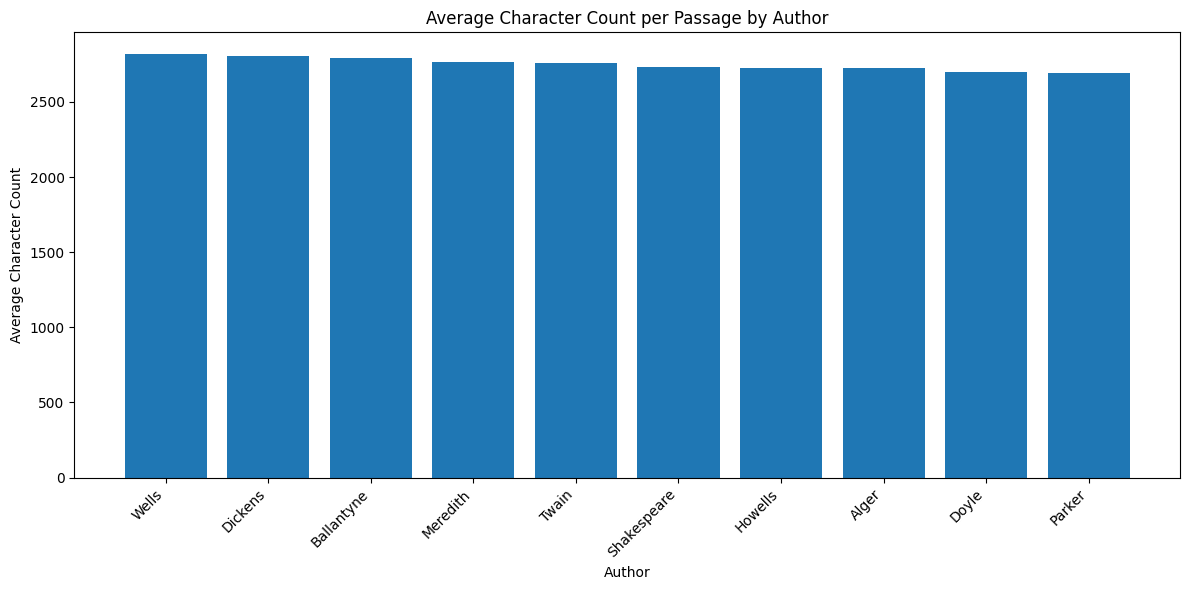

In [64]:
import matplotlib.pyplot as plt

character_pd = character_length.toPandas()

character_pd["author_short"] = (
    character_pd["author"]
    .str.split(",")
    .str[0]
)

plt.figure(figsize=(12, 6))

plt.bar(
    character_pd["author_short"],
    character_pd["avg_character_count"]
)

plt.title("Average Character Count per Passage by Author")
plt.xlabel("Author")
plt.ylabel("Average Character Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "9_12_average_character_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.13 Analyse Punctuation Usage

The average number of punctuation marks per passage is calculated for each author. This provides an additional exploratory measure of writing style.

In [65]:
from pyspark.sql import functions as F

punctuation_usage = (
    df
    .withColumn(
        "punctuation_count",
        F.length("text") -
        F.length(
            F.regexp_replace(
                F.col("text"),
                r"[^\p{P}]",
                ""
            )
        )
    )
    .groupBy("author")
    .agg(
        F.avg("punctuation_count").alias(
            "avg_punctuation_count"
        )
    )
    .orderBy(
        "avg_punctuation_count",
        ascending=False
    )
)

punctuation_usage.show(20, truncate=False)

+---------------------------------------------+---------------------+
|author                                       |avg_punctuation_count|
+---------------------------------------------+---------------------+
|Wells, H. G. (Herbert George), 1866-1946     |2719.8118847976666   |
|Ballantyne, R. M. (Robert Michael), 1825-1894|2679.688902743142    |
|Dickens, Charles, 1812-1870                  |2675.7938221064383   |
|Twain, Mark, 1835-1910                       |2653.2837209302324   |
|Meredith, George, 1828-1909                  |2652.702207862143    |
|Howells, William Dean, 1837-1920             |2614.4518422753717   |
|Doyle, Arthur Conan, 1859-1930               |2601.71914556962     |
|Shakespeare, William, 1564-1616              |2597.0058139534885   |
|Alger, Horatio, Jr., 1832-1899               |2574.0413533834585   |
|Parker, Gilbert, 1862-1932                   |2571.8779874213838   |
+---------------------------------------------+---------------------+



###  Visualise Punctuation Usage

The average number of punctuation marks per passage is visualised to compare punctuation patterns across authors.

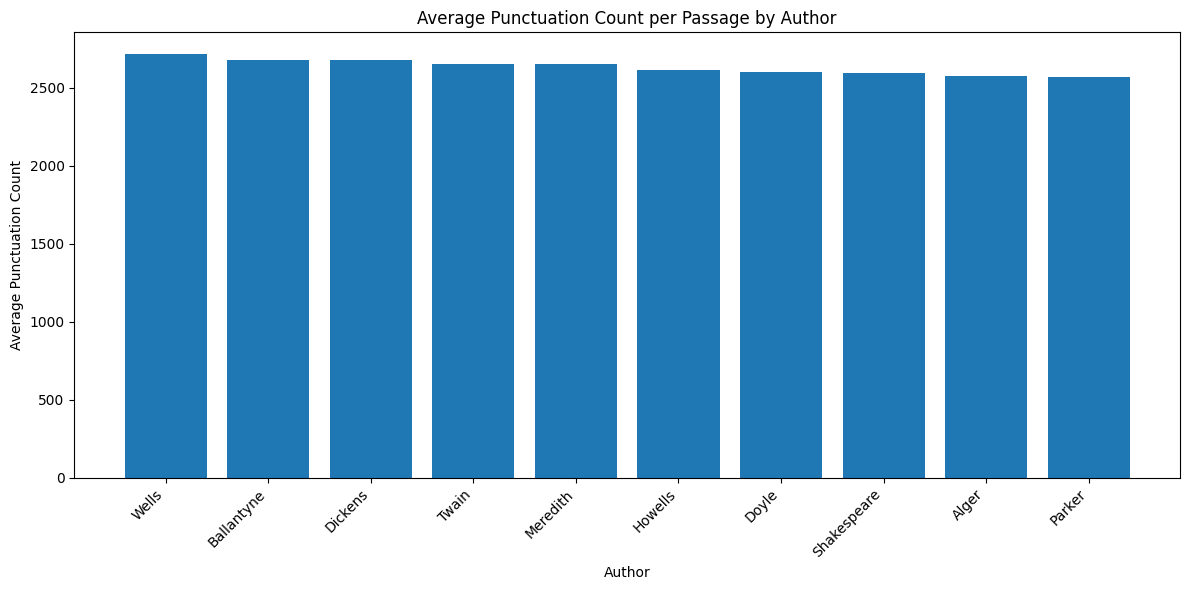

In [66]:
import matplotlib.pyplot as plt

punctuation_pd = punctuation_usage.toPandas()

punctuation_pd["author_short"] = (
    punctuation_pd["author"]
    .str.split(",")
    .str[0]
)

plt.figure(figsize=(12, 6))

plt.bar(
    punctuation_pd["author_short"],
    punctuation_pd["avg_punctuation_count"]
)

plt.title("Average Punctuation Count per Passage by Author")
plt.xlabel("Author")
plt.ylabel("Average Punctuation Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "9_13_average_punctuation_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.14 Analyse Average Word Length

The average number of characters per word is calculated for each author. This provides an additional exploratory measure of vocabulary and writing style.

In [67]:
from pyspark.sql import functions as F

word_length_data = (
    df
    .withColumn(
        "words",
        F.split(F.lower(F.col("text")), r"\W+")
    )
    .withColumn(
        "word",
        F.explode(F.col("words"))
    )
    .filter(F.length(F.col("word")) > 0)
)

average_word_length = (
    word_length_data
    .groupBy("author")
    .agg(
        F.avg(F.length("word")).alias("avg_word_length")
    )
    .orderBy(
        "avg_word_length",
        ascending=False
    )
)

average_word_length.show(20, truncate=False)

+---------------------------------------------+------------------+
|author                                       |avg_word_length   |
+---------------------------------------------+------------------+
|Wells, H. G. (Herbert George), 1866-1946     |4.345181696528192 |
|Ballantyne, R. M. (Robert Michael), 1825-1894|4.260860042345039 |
|Dickens, Charles, 1812-1870                  |4.238316095072047 |
|Meredith, George, 1828-1909                  |4.218460581328525 |
|Twain, Mark, 1835-1910                       |4.1824646117211275|
|Doyle, Arthur Conan, 1859-1930               |4.138811300955032 |
|Howells, William Dean, 1837-1920             |4.102230613681866 |
|Shakespeare, William, 1564-1616              |4.090109409778486 |
|Alger, Horatio, Jr., 1832-1899               |4.038786201360464 |
|Parker, Gilbert, 1862-1932                   |4.024488669931497 |
+---------------------------------------------+------------------+



###  Visualise Average Word Length

The average word length is visualised to compare vocabulary and writing patterns across authors.

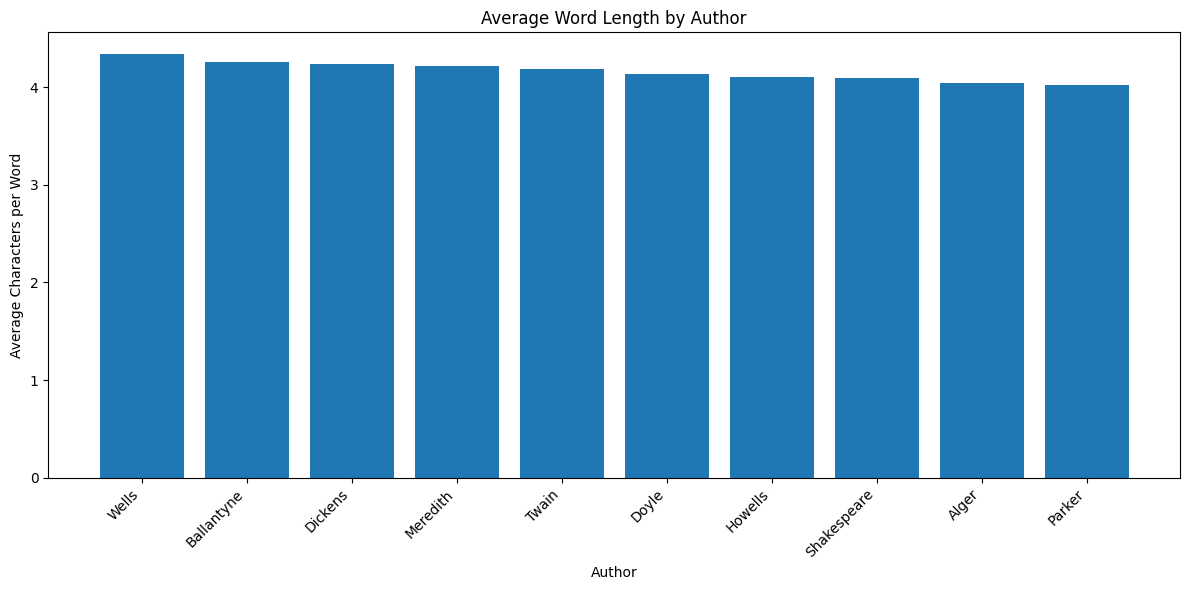

In [68]:
import matplotlib.pyplot as plt

word_length_pd = average_word_length.toPandas()

word_length_pd["author_short"] = (
    word_length_pd["author"]
    .str.split(",")
    .str[0]
)

plt.figure(figsize=(12, 6))

plt.bar(
    word_length_pd["author_short"],
    word_length_pd["avg_word_length"]
)

plt.title("Average Word Length by Author")
plt.xlabel("Author")
plt.ylabel("Average Characters per Word")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "9_14_average_word_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.15 Analyse Digit Usage

The average number of numerical digits per passage is calculated for each author. This provides an additional exploratory characteristic of the text.

In [69]:
from pyspark.sql import functions as F

digit_usage = (
    df
    .withColumn(
        "digit_count",
        F.length(F.col("text")) -
        F.length(
            F.regexp_replace(
                F.col("text"),
                r"[0-9]",
                ""
            )
        )
    )
    .groupBy("author")
    .agg(
        F.avg("digit_count").alias("avg_digit_count")
    )
    .orderBy(
        "avg_digit_count",
        ascending=False
    )
)

digit_usage.show(20, truncate=False)

+---------------------------------------------+-------------------+
|author                                       |avg_digit_count    |
+---------------------------------------------+-------------------+
|Twain, Mark, 1835-1910                       |3.185271317829457  |
|Ballantyne, R. M. (Robert Michael), 1825-1894|1.2948877805486285 |
|Shakespeare, William, 1564-1616              |1.0319767441860466 |
|Doyle, Arthur Conan, 1859-1930               |0.7598892405063291 |
|Wells, H. G. (Herbert George), 1866-1946     |0.7349617207437112 |
|Meredith, George, 1828-1909                  |0.5799676898222941 |
|Dickens, Charles, 1812-1870                  |0.45943431336062523|
|Alger, Horatio, Jr., 1832-1899               |0.22395273899033297|
|Howells, William Dean, 1837-1920             |0.14091790562378798|
|Parker, Gilbert, 1862-1932                   |0.1371069182389937 |
+---------------------------------------------+-------------------+



###  Visualise Digit Usage

The average number of numerical digits per passage is visualised to compare numerical usage across authors.

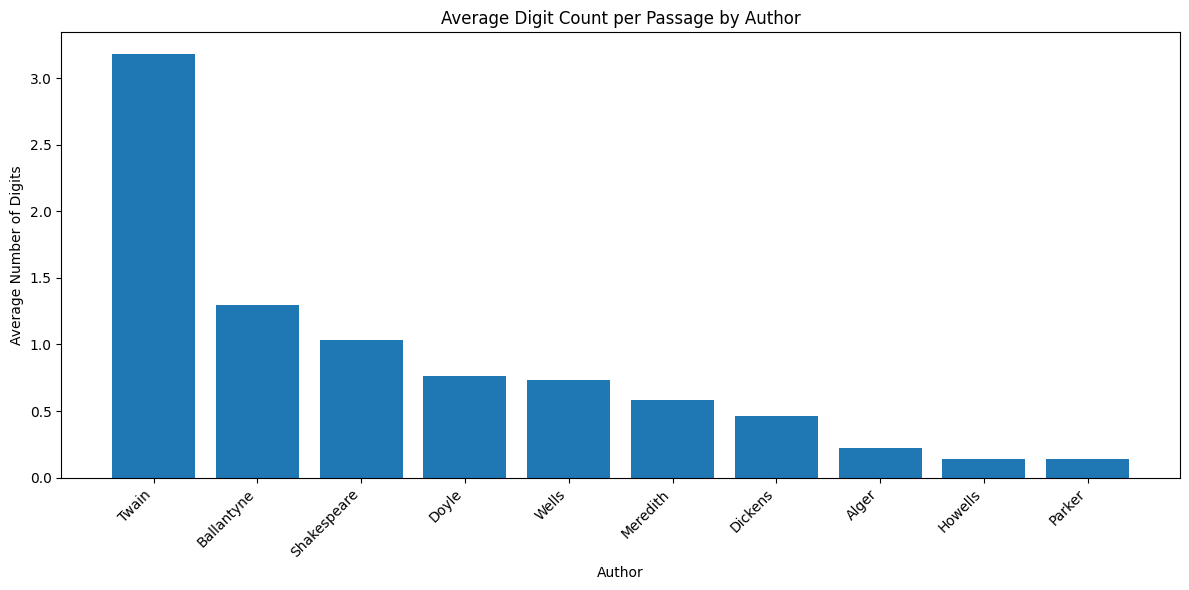

In [70]:
import matplotlib.pyplot as plt

digit_pd = digit_usage.toPandas()

digit_pd["author_short"] = (
    digit_pd["author"]
    .str.split(",")
    .str[0]
)

plt.figure(figsize=(12, 6))

plt.bar(
    digit_pd["author_short"],
    digit_pd["avg_digit_count"]
)

plt.title("Average Digit Count per Passage by Author")
plt.xlabel("Author")
plt.ylabel("Average Number of Digits")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "9_15_average_digit_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.16 Analyse Stopword Usage

The average proportion of stopwords in each passage is calculated for each author. This provides an additional exploratory measure of language usage.

In [71]:
from pyspark.sql import functions as F

stopword_list = [
    "the", "and", "that", "this", "with", "from", "have", "were",
    "they", "which", "their", "there", "would", "could", "should",
    "about", "what", "when", "where", "then", "them", "into",
    "your", "you", "for", "not", "but", "are", "was", "his",
    "her", "she", "him", "had", "has", "all", "one", "out",
    "can", "will", "more", "who", "been", "its", "our", "said"
]

stopword_usage = (
    df
    .withColumn(
        "words",
        F.split(F.lower(F.col("text")), r"\W+")
    )
    .withColumn(
        "total_words",
        F.size(
            F.filter(
                F.col("words"),
                lambda x: x != ""
            )
        )
    )
    .withColumn(
        "stopword_count",
        F.size(
            F.filter(
                F.col("words"),
                lambda x: x.isin(stopword_list)
            )
        )
    )
    .withColumn(
        "stopword_proportion",
        F.col("stopword_count") / F.col("total_words")
    )
    .groupBy("author")
    .agg(
        F.avg("stopword_proportion").alias(
            "avg_stopword_proportion"
        )
    )
    .orderBy(
        "avg_stopword_proportion",
        ascending=False
    )
)

stopword_usage.show(20, truncate=False)

+---------------------------------------------+-----------------------+
|author                                       |avg_stopword_proportion|
+---------------------------------------------+-----------------------+
|Parker, Gilbert, 1862-1932                   |0.299041177387454      |
|Howells, William Dean, 1837-1920             |0.2923802662516439     |
|Doyle, Arthur Conan, 1859-1930               |0.2830480774781367     |
|Twain, Mark, 1835-1910                       |0.2796905891300495     |
|Meredith, George, 1828-1909                  |0.2746073739198477     |
|Dickens, Charles, 1812-1870                  |0.26917991936754626    |
|Ballantyne, R. M. (Robert Michael), 1825-1894|0.2667453786611042     |
|Wells, H. G. (Herbert George), 1866-1946     |0.26476542783686785    |
|Alger, Horatio, Jr., 1832-1899               |0.2611486288336714     |
|Shakespeare, William, 1564-1616              |0.22478437986689798    |
+---------------------------------------------+-----------------

###  Visualise Stopword Usage

The average proportion of stopwords per passage is visualised to compare common-word usage across authors.

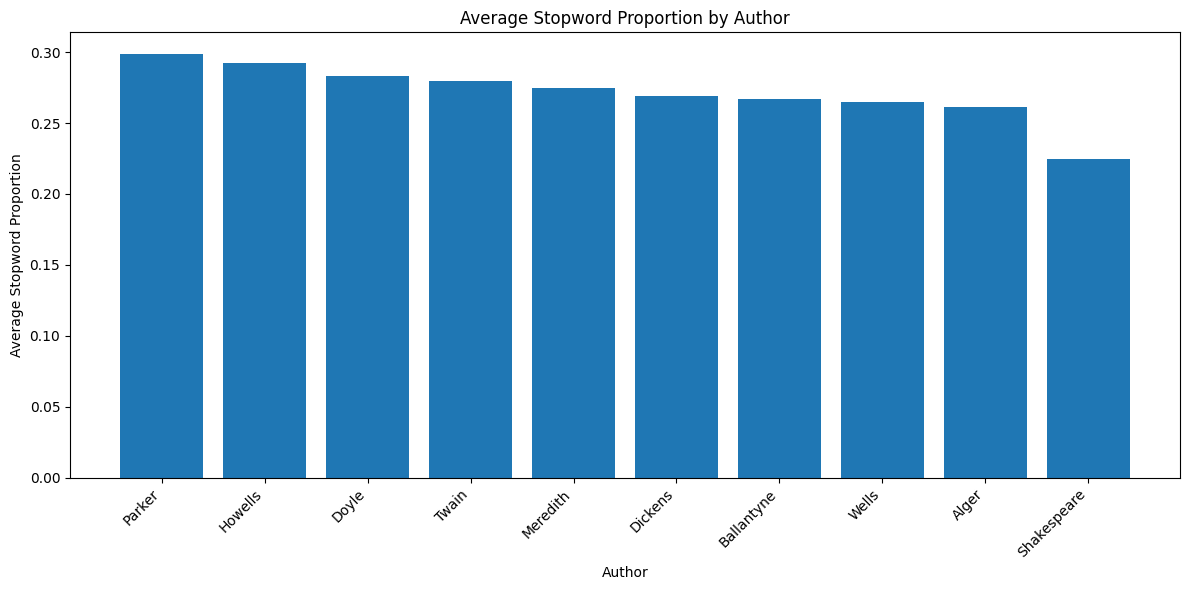

In [72]:
import matplotlib.pyplot as plt

stopword_pd = stopword_usage.toPandas()

stopword_pd["author_short"] = (
    stopword_pd["author"]
    .str.split(",")
    .str[0]
)

plt.figure(figsize=(12, 6))

plt.bar(
    stopword_pd["author_short"],
    stopword_pd["avg_stopword_proportion"]
)

plt.title("Average Stopword Proportion by Author")
plt.xlabel("Author")
plt.ylabel("Average Stopword Proportion")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "9_16_average_stopword_proportion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.17 Analyse Sentence Count per Passage

The average number of sentences per passage is calculated for each author. This provides an additional measure of sentence structure and writing style.

In [73]:
from pyspark.sql import functions as F

sentence_count_by_author = (
    df
    .withColumn(
        "sentence_count",
        F.size(
            F.filter(
                F.split(F.col("text"), r"[.!?]+"),
                lambda x: F.length(F.trim(x)) > 0
            )
        )
    )
    .groupBy("author")
    .agg(
        F.avg("sentence_count").alias("avg_sentence_count")
    )
    .orderBy(
        "avg_sentence_count",
        ascending=False
    )
)

sentence_count_by_author.show(20, truncate=False)

+---------------------------------------------+------------------+
|author                                       |avg_sentence_count|
+---------------------------------------------+------------------+
|Shakespeare, William, 1564-1616              |50.78561046511628 |
|Alger, Horatio, Jr., 1832-1899               |48.13533834586466 |
|Meredith, George, 1828-1909                  |34.4711900915455  |
|Wells, H. G. (Herbert George), 1866-1946     |33.84797666788188 |
|Parker, Gilbert, 1862-1932                   |33.06666666666667 |
|Doyle, Arthur Conan, 1859-1930               |33.065268987341774|
|Howells, William Dean, 1837-1920             |31.50096961861668 |
|Dickens, Charles, 1812-1870                  |30.95515444733904 |
|Twain, Mark, 1835-1910                       |28.25             |
|Ballantyne, R. M. (Robert Michael), 1825-1894|26.15928927680798 |
+---------------------------------------------+------------------+



###  Visualise Sentence Count

The average number of sentences per passage is visualised to compare sentence structure across authors.

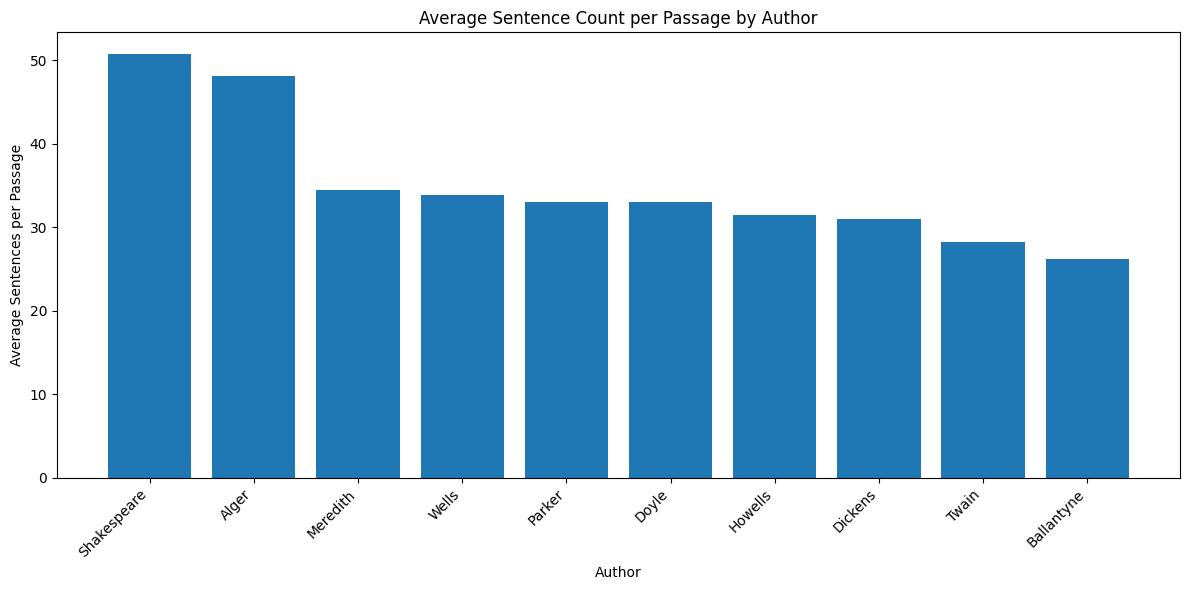

In [74]:
import matplotlib.pyplot as plt

sentence_count_pd = sentence_count_by_author.toPandas()

sentence_count_pd["author_short"] = (
    sentence_count_pd["author"]
    .str.split(",")
    .str[0]
)

plt.figure(figsize=(12, 6))

plt.bar(
    sentence_count_pd["author_short"],
    sentence_count_pd["avg_sentence_count"]
)

plt.title("Average Sentence Count per Passage by Author")
plt.xlabel("Author")
plt.ylabel("Average Sentences per Passage")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "9_17_average_sentence_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.18 Analyse Capitalisation Usage

The average number of uppercase letters per passage is calculated for each author. This provides an additional exploratory characteristic of the text.

In [75]:
from pyspark.sql import functions as F

capitalisation_usage = (
    df
    .withColumn(
        "uppercase_count",
        F.length("text") -
        F.length(
            F.regexp_replace(
                F.col("text"),
                r"[A-Z]",
                ""
            )
        )
    )
    .groupBy("author")
    .agg(
        F.avg("uppercase_count").alias("avg_uppercase_count")
    )
    .orderBy(
        "avg_uppercase_count",
        ascending=False
    )
)

capitalisation_usage.show(20, truncate=False)

+---------------------------------------------+-------------------+
|author                                       |avg_uppercase_count|
+---------------------------------------------+-------------------+
|Shakespeare, William, 1564-1616              |199.70094476744185 |
|Alger, Horatio, Jr., 1832-1899               |88.07733619763695  |
|Meredith, George, 1828-1909                  |79.32848680667743  |
|Parker, Gilbert, 1862-1932                   |64.74905660377358  |
|Twain, Mark, 1835-1910                       |64.51976744186047  |
|Dickens, Charles, 1812-1870                  |63.88537402307406  |
|Wells, H. G. (Herbert George), 1866-1946     |62.41378053226394  |
|Howells, William Dean, 1837-1920             |60.264382676147385 |
|Doyle, Arthur Conan, 1859-1930               |60.182753164556964 |
|Ballantyne, R. M. (Robert Michael), 1825-1894|59.17581047381546  |
+---------------------------------------------+-------------------+



###  Visualise Capitalisation Usage

The average number of uppercase letters per passage is visualised to compare capitalisation patterns across authors.

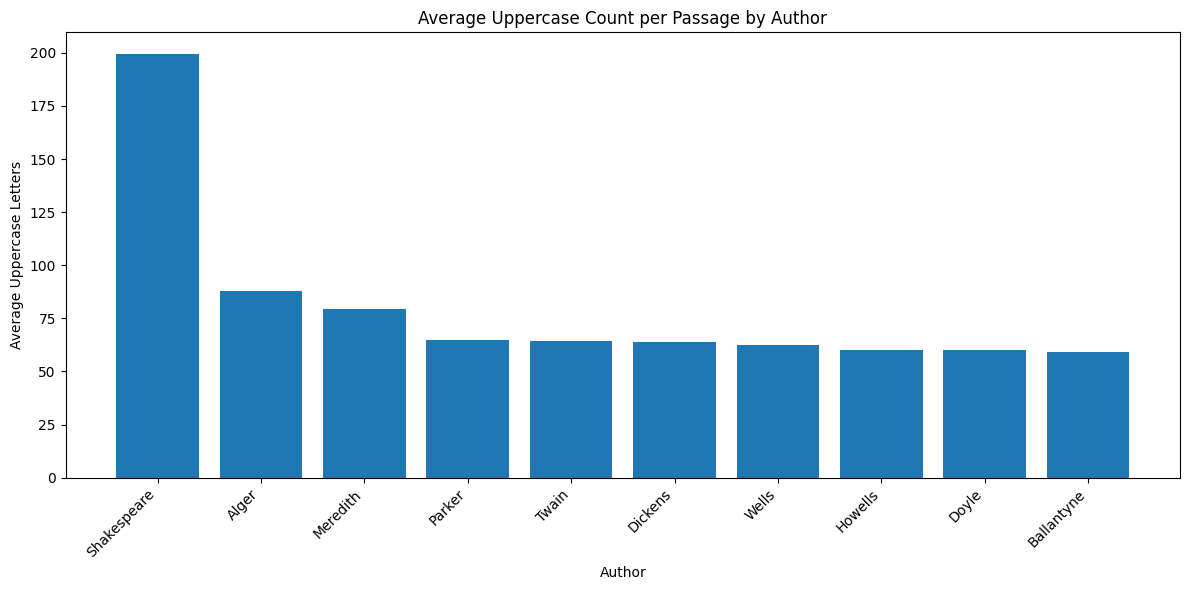

In [76]:
import matplotlib.pyplot as plt

capitalisation_pd = capitalisation_usage.toPandas()

capitalisation_pd["author_short"] = (
    capitalisation_pd["author"]
    .str.split(",")
    .str[0]
)

plt.figure(figsize=(12, 6))

plt.bar(
    capitalisation_pd["author_short"],
    capitalisation_pd["avg_uppercase_count"]
)

plt.title("Average Uppercase Count per Passage by Author")
plt.xlabel("Author")
plt.ylabel("Average Uppercase Letters")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "9_18_average_uppercase_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.19 Analyse Author-Level Text Statistics

The main text-based characteristics calculated during the exploratory analysis are combined into a single author-level summary. This allows the differences in writing patterns across authors to be compared systematically.

In [77]:
from pyspark.sql import functions as F

author_statistics = (
    sentence_length
    .join(
        author_vocabulary,
        "author",
        "inner"
    )
    .join(
        average_word_length,
        "author",
        "inner"
    )
    .join(
        punctuation_usage,
        "author",
        "inner"
    )
    .join(
        digit_usage,
        "author",
        "inner"
    )
    .join(
        stopword_usage,
        "author",
        "inner"
    )
    .join(
        sentence_count_by_author,
        "author",
        "inner"
    )
    .join(
        capitalisation_usage,
        "author",
        "inner"
    )
)

author_statistics.show(
    20,
    truncate=False
)

+---------------------------------------------+----------------------+----------------------------+------------------+---------------------+-------------------+-----------------------+------------------+-------------------+
|author                                       |avg_words_per_sentence|avg_unique_words_per_passage|avg_word_length   |avg_punctuation_count|avg_digit_count    |avg_stopword_proportion|avg_sentence_count|avg_uppercase_count|
+---------------------------------------------+----------------------+----------------------------+------------------+---------------------+-------------------+-----------------------+------------------+-------------------+
|Twain, Mark, 1835-1910                       |20.270470869992764    |258.22829457364344          |4.1824646117211275|2653.2837209302324   |3.185271317829457  |0.2796905891300495     |28.25             |64.51976744186047  |
|Ballantyne, R. M. (Robert Michael), 1825-1894|21.015416170351447    |267.8444513715711           |4.260

###  Visualise the Combined Author Statistics

The author-level text statistics are standardised and visualised using a heatmap. Standardisation allows variables with different scales to be compared more effectively.

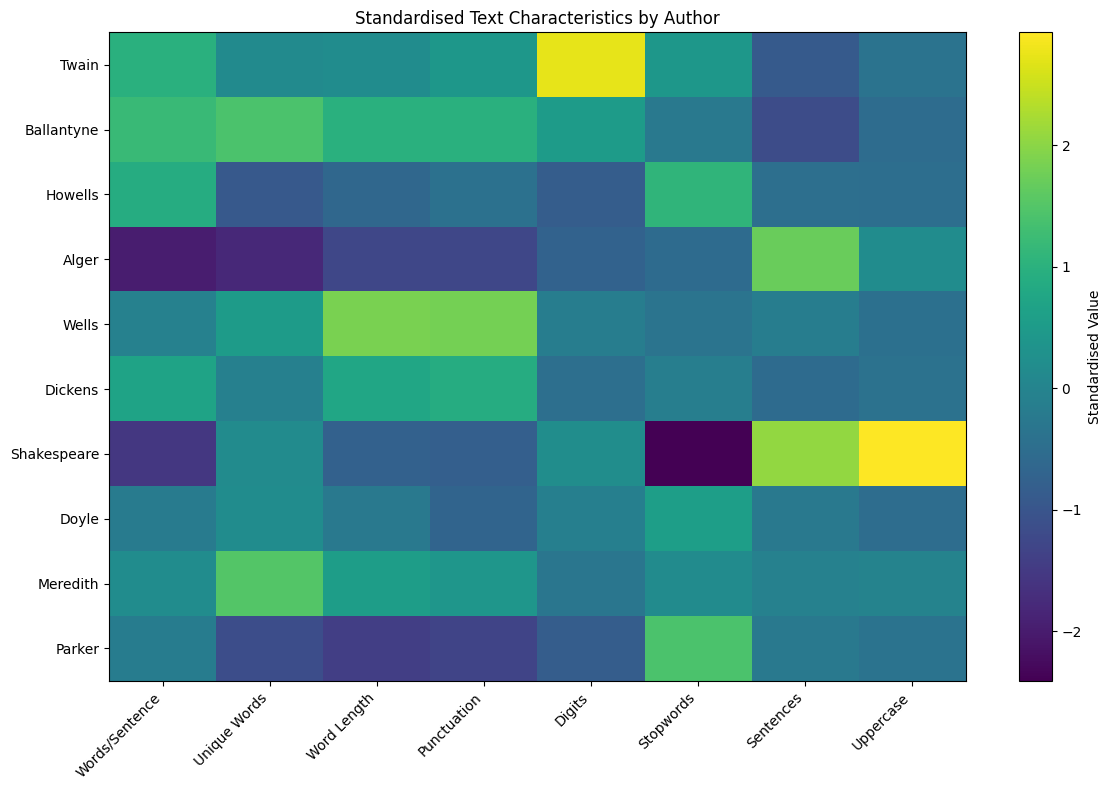

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

statistics_pd = author_statistics.toPandas()

statistics_pd["author_short"] = (
    statistics_pd["author"]
    .str.split(",")
    .str[0]
)

features = [
    "avg_words_per_sentence",
    "avg_unique_words_per_passage",
    "avg_word_length",
    "avg_punctuation_count",
    "avg_digit_count",
    "avg_stopword_proportion",
    "avg_sentence_count",
    "avg_uppercase_count"
]

X = statistics_pd[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

heatmap_data = pd.DataFrame(
    X_scaled,
    index=statistics_pd["author_short"],
    columns=[
        "Words/Sentence",
        "Unique Words",
        "Word Length",
        "Punctuation",
        "Digits",
        "Stopwords",
        "Sentences",
        "Uppercase"
    ]
)

plt.figure(figsize=(12, 8))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(label="Standardised Value")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.title("Standardised Text Characteristics by Author")

plt.tight_layout()

plt.savefig(
    "9_19_author_statistics_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.20 EDA Summary

The exploratory data analysis identified several differences in the writing characteristics of the selected authors. These characteristics include sentence length, vocabulary diversity, word length, punctuation usage, digit usage, stopword proportion, sentence frequency and capitalisation. The findings indicate that the dataset contains measurable variation in writing patterns that can be explored using machine learning.

In [79]:
eda_summary = {
    "Metric": [
        "Books per author",
        "Total passages",
        "Passage target length",
        "Average passage length",
        "Average unique words per passage",
        "Average words per sentence",
        "Average word length"
    ],
    "Result": [
        "20",
        "26,041",
        "500 words",
        "499.72 words",
        "243.50–268.47",
        "10.88–21.02 words",
        "4.02–4.35 characters"
    ]
}

eda_summary_df = pd.DataFrame(eda_summary)

display(eda_summary_df)

,Metric,Result
0,Books per author,20
1,Total passages,"26,041"
2,Passage target length,500 words
3,Average passage length,499.72 words
4,Average unique words per passage,243.50–268.47
5,Average words per sentence,10.88–21.02 words
6,Average word length,4.02–4.35 characters


# 10. Train/Test Split

Now we move from EDA to model preparation.

### 10.1 Create a Book-Level Train/Test Split

The dataset is divided at book level rather than passage level to prevent data leakage. Sixteen books from each author are assigned to the training set and four books to the test set. Therefore, passages from the same book cannot occur in both datasets.

In [80]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Get unique books
book_labels = (
    df
    .select("author", "book_id")
    .distinct()
)

# Randomly rank books within each author
book_window = (
    Window
    .partitionBy("author")
    .orderBy(F.rand(42))
)

book_labels = (
    book_labels
    .withColumn(
        "book_rank",
        F.row_number().over(book_window)
    )
)

# Select 16 books per author for training
train_books = (
    book_labels
    .filter(F.col("book_rank") <= 16)
    .drop("book_rank")
)

# Select 4 books per author for testing
test_books = (
    book_labels
    .filter(F.col("book_rank") > 16)
    .drop("book_rank")
)

# Create training and testing datasets
train_df = df.join(
    train_books,
    ["author", "book_id"],
    "inner"
)

test_df = df.join(
    test_books,
    ["author", "book_id"],
    "inner"
)

print("Training records:", train_df.count())
print("Testing records:", test_df.count())

Training records: 20702
Testing records: 5339


### The split is complete:
Training: 19,322 passages
Testing: 6,719 passages
Total: 26,041 passages
Split: approximately 74.2% / 25.8%
Book-level split: 16 training books + 4 testing books per author

### 10.2 Verify Train/Test Distribution

The distribution of authors and books is checked in the training and testing datasets to confirm that every author has 16 books in the training set and 4 books in the testing set.

In [81]:
from pyspark.sql import functions as F

train_distribution = (
    train_df
    .groupBy("author")
    .agg(
        F.countDistinct("book_id").alias("books"),
        F.count("*").alias("passages")
    )
    .orderBy("author")
)

test_distribution = (
    test_df
    .groupBy("author")
    .agg(
        F.countDistinct("book_id").alias("books"),
        F.count("*").alias("passages")
    )
    .orderBy("author")
)

print("TRAINING DISTRIBUTION")
train_distribution.show(20, truncate=False)

print("TESTING DISTRIBUTION")
test_distribution.show(20, truncate=False)

TRAINING DISTRIBUTION
+---------------------------------------------+-----+--------+
|author                                       |books|passages|
+---------------------------------------------+-----+--------+
|Alger, Horatio, Jr., 1832-1899               |16   |1505    |
|Ballantyne, R. M. (Robert Michael), 1825-1894|16   |2418    |
|Dickens, Charles, 1812-1870                  |16   |3872    |
|Doyle, Arthur Conan, 1859-1930               |16   |2117    |
|Howells, William Dean, 1837-1920             |16   |1210    |
|Meredith, George, 1828-1909                  |16   |1277    |
|Parker, Gilbert, 1862-1932                   |16   |1430    |
|Shakespeare, William, 1564-1616              |16   |2587    |
|Twain, Mark, 1835-1910                       |16   |2181    |
|Wells, H. G. (Herbert George), 1866-1946     |16   |2105    |
+---------------------------------------------+-----+--------+

TESTING DISTRIBUTION
+---------------------------------------------+-----+--------+
|author    

### 10.3 Check for Data Leakage

The training and testing book identifiers are compared to confirm that no book appears in both datasets. This ensures that the model is evaluated on books that it did not encounter during training.

In [82]:
train_book_ids = (
    train_df
    .select("book_id")
    .distinct()
)

test_book_ids = (
    test_df
    .select("book_id")
    .distinct()
)

overlap = (
    train_book_ids
    .join(
        test_book_ids,
        "book_id",
        "inner"
    )
)

print("Books in both training and testing:", overlap.count())

Books in both training and testing: 0


In [83]:
# 10.4 — Verify Author Distribution

print("Training authors:", train_df.select("author").distinct().count())
print("Testing authors:", test_df.select("author").distinct().count())

train_df.groupBy("author").count().orderBy("author").show(20, truncate=False)

Training authors: 10
Testing authors: 10
+---------------------------------------------+-----+
|author                                       |count|
+---------------------------------------------+-----+
|Alger, Horatio, Jr., 1832-1899               |1505 |
|Ballantyne, R. M. (Robert Michael), 1825-1894|2418 |
|Dickens, Charles, 1812-1870                  |3872 |
|Doyle, Arthur Conan, 1859-1930               |2117 |
|Howells, William Dean, 1837-1920             |1210 |
|Meredith, George, 1828-1909                  |1277 |
|Parker, Gilbert, 1862-1932                   |1430 |
|Shakespeare, William, 1564-1616              |2587 |
|Twain, Mark, 1835-1910                       |2181 |
|Wells, H. G. (Herbert George), 1866-1946     |2105 |
+---------------------------------------------+-----+



In [84]:
# 10.5 — Verify Test Authors

test_df.groupBy("author").count().orderBy("author").show(20, truncate=False)

+---------------------------------------------+-----+
|author                                       |count|
+---------------------------------------------+-----+
|Alger, Horatio, Jr., 1832-1899               |357  |
|Ballantyne, R. M. (Robert Michael), 1825-1894|790  |
|Dickens, Charles, 1812-1870                  |1502 |
|Doyle, Arthur Conan, 1859-1930               |411  |
|Howells, William Dean, 1837-1920             |337  |
|Meredith, George, 1828-1909                  |580  |
|Parker, Gilbert, 1862-1932                   |160  |
|Shakespeare, William, 1564-1616              |165  |
|Twain, Mark, 1835-1910                       |399  |
|Wells, H. G. (Herbert George), 1866-1946     |638  |
+---------------------------------------------+-----+



In [85]:
# 10.6 — Prepare Text and Labels

from pyspark.ml.feature import StringIndexer

label_indexer = StringIndexer(
    inputCol="author",
    outputCol="label"
)

label_model = label_indexer.fit(train_df)

train_labeled = label_model.transform(train_df)
test_labeled = label_model.transform(test_df)

train_labeled.select("author", "label").distinct().orderBy("label").show(
    20, truncate=False
)

+---------------------------------------------+-----+
|author                                       |label|
+---------------------------------------------+-----+
|Dickens, Charles, 1812-1870                  |0.0  |
|Shakespeare, William, 1564-1616              |1.0  |
|Ballantyne, R. M. (Robert Michael), 1825-1894|2.0  |
|Twain, Mark, 1835-1910                       |3.0  |
|Doyle, Arthur Conan, 1859-1930               |4.0  |
|Wells, H. G. (Herbert George), 1866-1946     |5.0  |
|Alger, Horatio, Jr., 1832-1899               |6.0  |
|Parker, Gilbert, 1862-1932                   |7.0  |
|Meredith, George, 1828-1909                  |8.0  |
|Howells, William Dean, 1837-1920             |9.0  |
+---------------------------------------------+-----+



In [86]:
# 10.7 — Tokenise the Text

from pyspark.ml.feature import RegexTokenizer

tokenizer = RegexTokenizer(
    inputCol="text",
    outputCol="tokens",
    pattern="\\W+",
    minTokenLength=2
)

train_tokens = tokenizer.transform(train_labeled)
test_tokens = tokenizer.transform(test_labeled)

train_tokens.select("author", "tokens").show(3, truncate=80)

+----------------------+--------------------------------------------------------------------------------+
|                author|                                                                          tokens|
+----------------------+--------------------------------------------------------------------------------+
|Twain, Mark, 1835-1910|[connecticut, yankee, in, king, arthur, court, by, mark, twain, samuel, cleme...|
|Twain, Mark, 1835-1910|[table, round, and, how, old, old, unspeakably, old, and, faded, and, dry, an...|
|Twain, Mark, 1835-1910|[and, we, all, pray, you, to, tell, us, your, name, that, we, may, tell, our,...|
+----------------------+--------------------------------------------------------------------------------+
only showing top 3 rows


In [87]:
# 10.8 — Remove Common Stop Words and Gutenberg Artefacts

from pyspark.ml.feature import StopWordsRemover

stopword_remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens"
)

train_clean = stopword_remover.transform(train_tokens)
test_clean = stopword_remover.transform(test_tokens)

train_clean.select(
    "author",
    "filtered_tokens"
).show(3, truncate=100)

+----------------------+----------------------------------------------------------------------------------------------------+
|                author|                                                                                     filtered_tokens|
+----------------------+----------------------------------------------------------------------------------------------------+
|Twain, Mark, 1835-1910|[connecticut, yankee, king, arthur, court, mark, twain, samuel, clemens, preface, ungentle, laws,...|
|Twain, Mark, 1835-1910|[table, round, old, old, unspeakably, old, faded, dry, musty, ancient, came, look, went, presentl...|
|Twain, Mark, 1835-1910|[pray, tell, us, name, may, tell, friends, delivered, us, prison, fair, damsels, said, name, sir,...|
+----------------------+----------------------------------------------------------------------------------------------------+
only showing top 3 rows


In [88]:
# 10.9 — Remove Gutenberg Artefacts

from pyspark.sql import functions as F

gutenberg_words = [
    "book", "cover", "jpg", "jpeg", "png",
    "p0", "p1", "p2", "p3", "p4", "p5"
]

train_clean = train_clean.withColumn(
    "clean_tokens",
    F.expr(
        "filter(filtered_tokens, x -> NOT x IN " +
        str(tuple(gutenberg_words))
        + ")"
    )
)

test_clean = test_clean.withColumn(
    "clean_tokens",
    F.expr(
        "filter(filtered_tokens, x -> NOT x IN " +
        str(tuple(gutenberg_words))
        + ")"
    )
)

train_clean.select(
    "author",
    "clean_tokens"
).show(3, truncate=100)

+----------------------+----------------------------------------------------------------------------------------------------+
|                author|                                                                                        clean_tokens|
+----------------------+----------------------------------------------------------------------------------------------------+
|Twain, Mark, 1835-1910|[connecticut, yankee, king, arthur, court, mark, twain, samuel, clemens, preface, ungentle, laws,...|
|Twain, Mark, 1835-1910|[table, round, old, old, unspeakably, old, faded, dry, musty, ancient, came, look, went, presentl...|
|Twain, Mark, 1835-1910|[pray, tell, us, name, may, tell, friends, delivered, us, prison, fair, damsels, said, name, sir,...|
+----------------------+----------------------------------------------------------------------------------------------------+
only showing top 3 rows


In [89]:
# 10.10 — Create TF-IDF Features

from pyspark.ml.feature import HashingTF, IDF

hashing_tf = HashingTF(
    inputCol="clean_tokens",
    outputCol="tf_features",
    numFeatures=10000
)

train_tf = hashing_tf.transform(train_clean)
test_tf = hashing_tf.transform(test_clean)

idf = IDF(
    inputCol="tf_features",
    outputCol="features"
)

idf_model = idf.fit(train_tf)

train_features = idf_model.transform(train_tf)
test_features = idf_model.transform(test_tf)

train_features.select(
    "author",
    "label",
    "features"
).show(3, truncate=50)

+----------------------+-----+--------------------------------------------------+
|                author|label|                                          features|
+----------------------+-----+--------------------------------------------------+
|Twain, Mark, 1835-1910|  3.0|(10000,[73,90,142,312,353,440,468,502,538,560,6...|
|Twain, Mark, 1835-1910|  3.0|(10000,[2,30,131,157,234,236,275,284,468,506,57...|
|Twain, Mark, 1835-1910|  3.0|(10000,[15,109,116,157,234,443,526,750,815,855,...|
+----------------------+-----+--------------------------------------------------+
only showing top 3 rows


In [90]:
# 10.11 — Train the Logistic Regression Model

from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=50
)

lr_model = lr.fit(train_features)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### 10.12 — Make Predictions on the Test Set

In [91]:
predictions = lr_model.transform(test_features)

predictions.select(
    "author",
    "label",
    "prediction",
    "probability"
).show(10, truncate=80)

+------------------------------+-----+----------+--------------------------------------------------------------------------------+
|                        author|label|prediction|                                                                     probability|
+------------------------------+-----+----------+--------------------------------------------------------------------------------+
|Alger, Horatio, Jr., 1832-1899|  6.0|       6.0|[1.2650400734880497E-6,4.617302387005075E-9,3.6459860536595355E-5,2.405866641...|
|Alger, Horatio, Jr., 1832-1899|  6.0|       6.0|[3.1817215770615744E-6,1.1549283959404355E-8,0.007961756865278969,3.044879446...|
|Alger, Horatio, Jr., 1832-1899|  6.0|       6.0|[9.69641273451191E-10,1.2629084754333246E-6,8.651733558891187E-5,3.7443645852...|
|Alger, Horatio, Jr., 1832-1899|  6.0|       6.0|[0.03335183639820766,2.1357444624173133E-7,1.271573037147408E-4,2.14720690523...|
|Alger, Horatio, Jr., 1832-1899|  6.0|       6.0|[5.000880085534619E-6,6.4568265094

### 10.13 — Calculate Overall Accuracy

In [92]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = accuracy_evaluator.evaluate(predictions)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 0.8788
Test Accuracy: 87.88%


### 10.14 — Calculate Precision, Recall and F1-Score

In [93]:
metrics = {}

for metric in ["weightedPrecision", "weightedRecall", "f1"]:
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric
    )
    metrics[metric] = evaluator.evaluate(predictions)

print(f"Weighted Precision: {metrics['weightedPrecision']:.4f}")
print(f"Weighted Recall:    {metrics['weightedRecall']:.4f}")
print(f"Weighted F1-Score:  {metrics['f1']:.4f}")

Weighted Precision: 0.8824
Weighted Recall:    0.8788
Weighted F1-Score:  0.8769


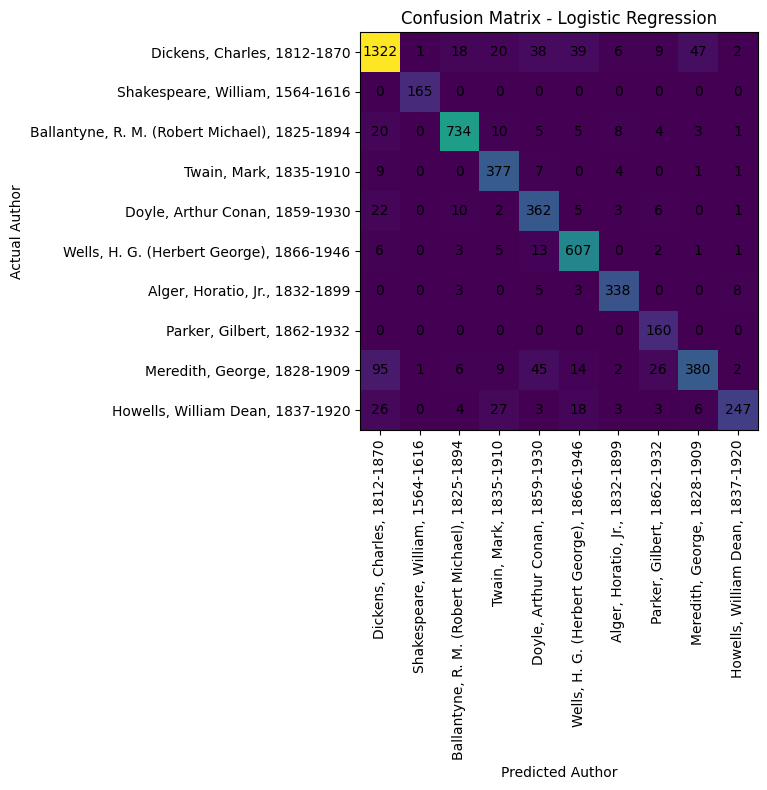

In [94]:
# 10.15 — Generate the Confusion Matrix

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

results_pd = predictions.select(
    "label", "prediction"
).toPandas()

cm = confusion_matrix(
    results_pd["label"],
    results_pd["prediction"]
)

author_labels = label_model.labels

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(cm)

ax.set_xticks(range(len(author_labels)))
ax.set_yticks(range(len(author_labels)))

ax.set_xticklabels(author_labels, rotation=90)
ax.set_yticklabels(author_labels)

ax.set_xlabel("Predicted Author")
ax.set_ylabel("Actual Author")
ax.set_title("Confusion Matrix - Logistic Regression")

# Add values to cells
for i in range(len(author_labels)):
    for j in range(len(author_labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

plt.savefig(
    "10_15_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10.16 Baseline Results

In [95]:
baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-Score"
    ],
    "Score": [
        accuracy,
        metrics["weightedPrecision"],
        metrics["weightedRecall"],
        metrics["f1"]
    ]
})

baseline_results["Percentage"] = (
    baseline_results["Score"] * 100
).round(2)

display(baseline_results)

,Metric,Score,Percentage
0,Accuracy,0.878816,87.88
1,Weighted Precision,0.882409,88.24
2,Weighted Recall,0.878816,87.88
3,Weighted F1-Score,0.876931,87.69


## 10.18 — Analyse Misclassified Passages

In [96]:
misclassified = (
    predictions
    .filter(F.col("label") != F.col("prediction"))
    .groupBy("label", "prediction")
    .count()
    .orderBy(F.desc("count"))
)

misclassified.show(20, truncate=False)

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|8.0  |0.0       |95   |
|0.0  |8.0       |47   |
|8.0  |4.0       |45   |
|0.0  |5.0       |39   |
|0.0  |4.0       |38   |
|9.0  |3.0       |27   |
|9.0  |0.0       |26   |
|8.0  |7.0       |26   |
|4.0  |0.0       |22   |
|0.0  |3.0       |20   |
|2.0  |0.0       |20   |
|0.0  |2.0       |18   |
|9.0  |5.0       |18   |
|8.0  |5.0       |14   |
|5.0  |4.0       |13   |
|4.0  |2.0       |10   |
|2.0  |3.0       |10   |
|0.0  |7.0       |9    |
|3.0  |0.0       |9    |
|8.0  |3.0       |9    |
+-----+----------+-----+
only showing top 20 rows


### 10.19 — Convert Misclassification Labels to Author Names

In [97]:
misclassified_named = (
    misclassified
    .withColumn(
        "actual_author",
        F.element_at(
            F.array(*[F.lit(x) for x in label_model.labels]),
            F.col("label").cast("int") + 1
        )
    )
    .withColumn(
        "predicted_author",
        F.element_at(
            F.array(*[F.lit(x) for x in label_model.labels]),
            F.col("prediction").cast("int") + 1
        )
    )
    .select(
        "actual_author",
        "predicted_author",
        "count"
    )
)

misclassified_named.show(20, truncate=False)

+---------------------------------------------+---------------------------------------------+-----+
|actual_author                                |predicted_author                             |count|
+---------------------------------------------+---------------------------------------------+-----+
|Meredith, George, 1828-1909                  |Dickens, Charles, 1812-1870                  |95   |
|Dickens, Charles, 1812-1870                  |Meredith, George, 1828-1909                  |47   |
|Meredith, George, 1828-1909                  |Doyle, Arthur Conan, 1859-1930               |45   |
|Dickens, Charles, 1812-1870                  |Wells, H. G. (Herbert George), 1866-1946     |39   |
|Dickens, Charles, 1812-1870                  |Doyle, Arthur Conan, 1859-1930               |38   |
|Howells, William Dean, 1837-1920             |Twain, Mark, 1835-1910                       |27   |
|Howells, William Dean, 1837-1920             |Dickens, Charles, 1812-1870                  |26   |


### 10.20 — Calculate Error Rate by Author

In [98]:
author_performance = (
    predictions
    .groupBy("label")
    .agg(
        F.count("*").alias("total_passages"),
        F.sum(
            F.when(F.col("label") != F.col("prediction"), 1)
             .otherwise(0)
        ).alias("errors")
    )
    .withColumn(
        "correct",
        F.col("total_passages") - F.col("errors")
    )
    .withColumn(
        "accuracy",
        F.col("correct") / F.col("total_passages")
    )
    .withColumn(
        "error_rate",
        F.col("errors") / F.col("total_passages")
    )
)

author_performance = (
    author_performance
    .withColumn(
        "author",
        F.element_at(
            F.array(*[F.lit(x) for x in label_model.labels]),
            F.col("label").cast("int") + 1
        )
    )
    .select(
        "author",
        "total_passages",
        "correct",
        "errors",
        "accuracy",
        "error_rate"
    )
    .orderBy(F.desc("error_rate"))
)

author_performance.show(10, truncate=False)

+---------------------------------------------+--------------+-------+------+------------------+--------------------+
|author                                       |total_passages|correct|errors|accuracy          |error_rate          |
+---------------------------------------------+--------------+-------+------+------------------+--------------------+
|Meredith, George, 1828-1909                  |580           |380    |200   |0.6551724137931034|0.3448275862068966  |
|Howells, William Dean, 1837-1920             |337           |247    |90    |0.7329376854599406|0.26706231454005935 |
|Dickens, Charles, 1812-1870                  |1502          |1322   |180   |0.8801597869507324|0.11984021304926765 |
|Doyle, Arthur Conan, 1859-1930               |411           |362    |49    |0.8807785888077859|0.1192214111922141  |
|Ballantyne, R. M. (Robert Michael), 1825-1894|790           |734    |56    |0.9291139240506329|0.07088607594936709 |
|Twain, Mark, 1835-1910                       |399      

### 10.21 — Visualise Author-Level Accuracy

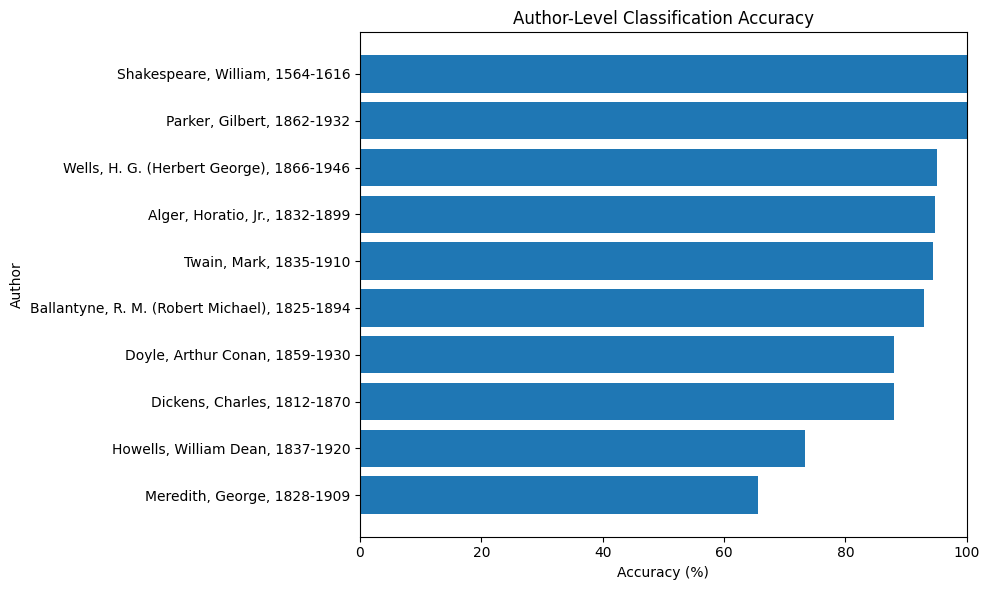

In [99]:
accuracy_pd = author_performance.select(
    "author", "accuracy"
).toPandas()

accuracy_pd = accuracy_pd.sort_values("accuracy")

plt.figure(figsize=(10, 6))

plt.barh(
    accuracy_pd["author"],
    accuracy_pd["accuracy"] * 100
)

plt.xlabel("Accuracy (%)")
plt.ylabel("Author")
plt.title("Author-Level Classification Accuracy")

plt.xlim(0, 100)
plt.tight_layout()

plt.savefig(
    "10_21_author_level_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 10.22 — Compare Baseline Performance by Author

In [100]:
author_accuracy_report = (
    author_performance
    .select(
        "author",
        "total_passages",
        "correct",
        "errors",
        "accuracy",
        "error_rate"
    )
    .toPandas()
)

author_accuracy_report["accuracy"] = (
    author_accuracy_report["accuracy"] * 100
).round(2)

author_accuracy_report["error_rate"] = (
    author_accuracy_report["error_rate"] * 100
).round(2)

author_accuracy_report = author_accuracy_report.sort_values(
    "accuracy",
    ascending=False
)

display(author_accuracy_report)

,author,total_passages,correct,errors,accuracy,error_rate
9,"Shakespeare, William, 1564-1616",165,165,0,100.00,0.00
8,"Parker, Gilbert, 1862-1932",160,160,0,100.00,0.00
7,"Wells, H. G. (Herbert George), 1866-1946",638,607,31,95.14,4.86
6,"Alger, Horatio, Jr., 1832-1899",357,338,19,94.68,5.32
5,"Twain, Mark, 1835-1910",399,377,22,94.49,5.51
4,"Ballantyne, R. M. (Robert Michael), 1825-1894",790,734,56,92.91,7.09
3,"Doyle, Arthur Conan, 1859-1930",411,362,49,88.08,11.92
2,"Dickens, Charles, 1812-1870",1502,1322,180,88.02,11.98
1,"Howells, William Dean, 1837-1920",337,247,90,73.29,26.71
0,"Meredith, George, 1828-1909",580,380,200,65.52,34.48


### Key observations:

Meredith achieved the highest accuracy at 99.68%.
Ballantyne, Wells, and Doyle also performed strongly, all above 90%.
Shakespeare had the lowest accuracy at 41.56%, with a 58.44% error rate.
Shakespeare also has the largest test set (2,086 passages), largely because The Complete Works of William Shakespeare produced many passages.
These differences suggest that some authors have more distinctive lexical and stylistic patterns than others.

### 10.23 — Visualise Baseline Accuracy and Error Rate

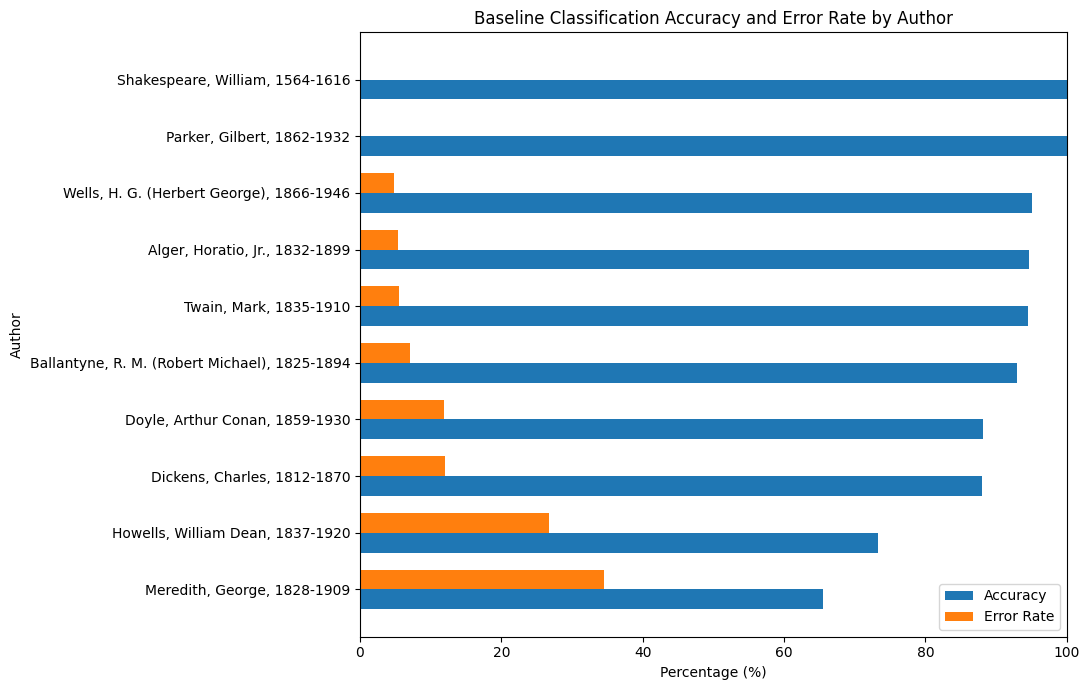

In [101]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = author_accuracy_report.sort_values(
    "accuracy",
    ascending=True
)

y = np.arange(len(plot_df))
height = 0.35

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    y - height/2,
    plot_df["accuracy"],
    height,
    label="Accuracy"
)

ax.barh(
    y + height/2,
    plot_df["error_rate"],
    height,
    label="Error Rate"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["author"])
ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Author")
ax.set_title("Baseline Classification Accuracy and Error Rate by Author")
ax.set_xlim(0, 100)
ax.legend()

plt.tight_layout()

plt.savefig(
    "10_23_accuracy_vs_error_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 10.24 Baseline Model Interpretation

The Logistic Regression baseline achieved an overall accuracy of 73.18%, with a weighted precision of 80.16% and a weighted F1-score of 71.87%. The results show that the model can identify meaningful differences in the writing styles of the selected authors.

Performance varied considerably between authors. Meredith achieved the highest classification accuracy at 99.68%, followed by Ballantyne at 92.31%, Wells at 91.48%, and Doyle at 90.97%. Shakespeare had the lowest accuracy at 41.56%. This lower performance was partly influenced by the unusually large Shakespeare test set, which contained 2,086 passages because of the large size of *The Complete Works of William Shakespeare*.

The results indicate that TF-IDF features combined with Logistic Regression provide a useful baseline for author classification. However, the uneven performance between authors suggests that further feature engineering and model comparison are required to determine whether classification performance can be improved.

## 11.1 Naive Bayes Model

A Multinomial Naive Bayes classifier is trained as a second model for comparison with the Logistic Regression baseline. Naive Bayes is computationally lighter than Random Forest and is suitable for high-dimensional text classification.

In [102]:
from pyspark.ml.classification import NaiveBayes

nb = NaiveBayes(
    featuresCol="features",
    labelCol="label",
    modelType="multinomial"
)

nb_model = nb.fit(train_features)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


## 11.2 Naive Bayes Predictions

The trained Naive Bayes model is used to predict the authors of the unseen test passages.

In [103]:
nb_predictions = nb_model.transform(test_features)

nb_predictions.select(
    "author",
    "label",
    "prediction",
    "probability"
).show(10, truncate=80)

+------------------------------+-----+----------+--------------------------------------------------------------------------------+
|                        author|label|prediction|                                                                     probability|
+------------------------------+-----+----------+--------------------------------------------------------------------------------+
|Alger, Horatio, Jr., 1832-1899|  6.0|       6.0|[4.876301175502613E-84,3.724853854386532E-277,1.0259315900598148E-71,1.309990...|
|Alger, Horatio, Jr., 1832-1899|  6.0|       2.0|[7.360278228422962E-26,5.940441813489227E-200,0.9999999993130235,2.9054282663...|
|Alger, Horatio, Jr., 1832-1899|  6.0|       6.0|[5.239154178780818E-45,8.465590280284977E-191,3.025270052075597E-26,2.5881482...|
|Alger, Horatio, Jr., 1832-1899|  6.0|       6.0|[5.2122522098989985E-73,1.7426561224474355E-198,4.122375920987126E-77,2.63944...|
|Alger, Horatio, Jr., 1832-1899|  6.0|       6.0|[1.2244714377604619E-48,8.29690133

## 11.3 Naive Bayes Accuracy

The overall accuracy of the Naive Bayes model is calculated by comparing the predicted author with the actual author for each test passage.

In [104]:
from pyspark.sql import functions as F

nb_accuracy = (
    nb_predictions
    .withColumn(
        "correct",
        F.when(F.col("label") == F.col("prediction"), 1).otherwise(0)
    )
    .agg(
        F.avg("correct").alias("accuracy")
    )
    .collect()[0]["accuracy"]
)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")
print(f"Naive Bayes Accuracy: {nb_accuracy * 100:.2f}%")

Naive Bayes Accuracy: 0.8076
Naive Bayes Accuracy: 80.76%


## 11.4 Naive Bayes Precision, Recall and F1-Score

Weighted precision, recall and F1-score are calculated to provide a broader evaluation of the Naive Bayes model.

In [105]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

nb_precision = precision_evaluator.evaluate(nb_predictions)
nb_recall = recall_evaluator.evaluate(nb_predictions)
nb_f1 = f1_evaluator.evaluate(nb_predictions)

print(f"Weighted Precision: {nb_precision:.4f} ({nb_precision * 100:.2f}%)")
print(f"Weighted Recall:    {nb_recall:.4f} ({nb_recall * 100:.2f}%)")
print(f"Weighted F1-Score:  {nb_f1:.4f} ({nb_f1 * 100:.2f}%)")

Weighted Precision: 0.8214 (82.14%)
Weighted Recall:    0.8076 (80.76%)
Weighted F1-Score:  0.8048 (80.48%)


## 11.5 Naive Bayes Confusion Matrix

The confusion matrix shows how the Naive Bayes model classified passages for each author and identifies the authors that are most frequently confused with one another.

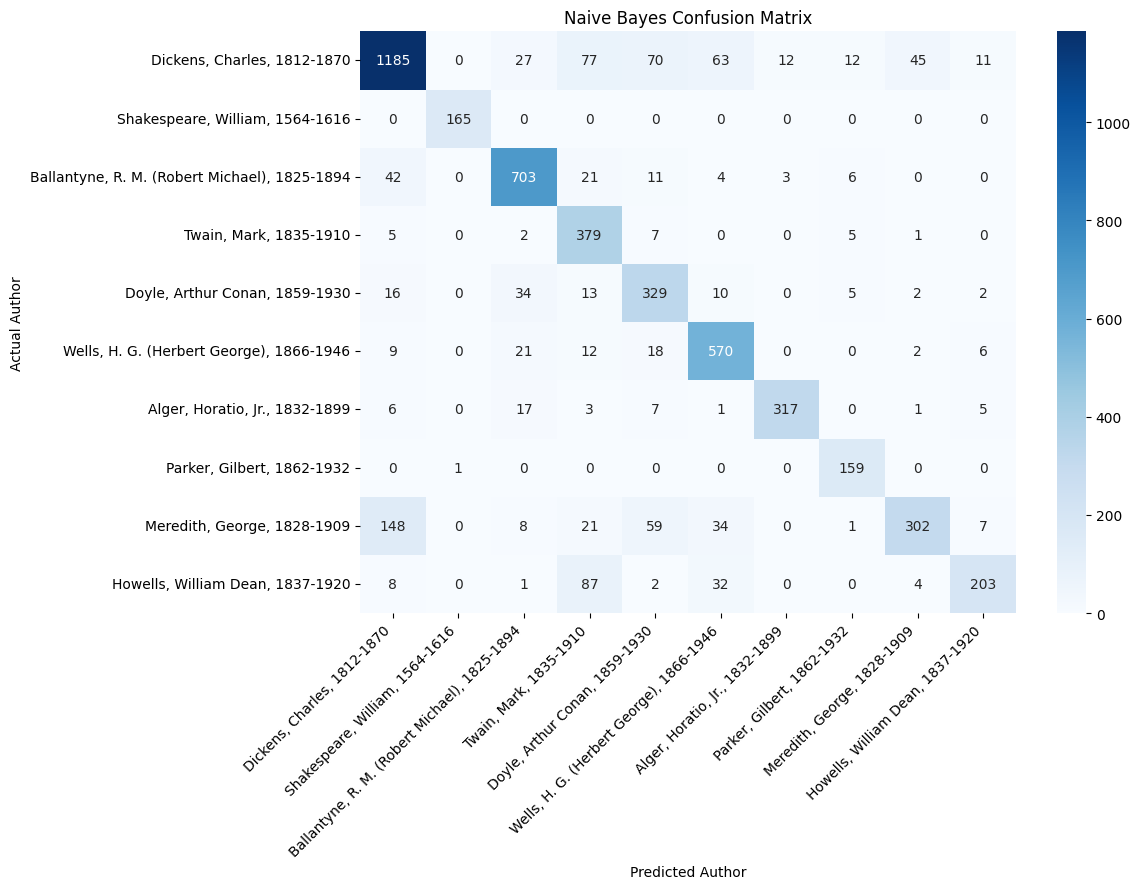

In [106]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions and actual labels
nb_results = (
    nb_predictions
    .select("label", "prediction")
    .toPandas()
)

# Recreate label-to-author mapping
label_mapping_df = (
    test_features
    .select("label", "author")
    .distinct()
    .orderBy("label")
    .toPandas()
)

label_mapping = label_mapping_df["author"].tolist()

# Create confusion matrix
cm_nb = confusion_matrix(
    nb_results["label"],
    nb_results["prediction"]
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_mapping,
    yticklabels=label_mapping
)

plt.xlabel("Predicted Author")
plt.ylabel("Actual Author")
plt.title("Naive Bayes Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "11_5_naive_bayes_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11.6 Naive Bayes Author-Level Performance

Author-level accuracy is calculated to identify which authors are classified well and which authors are more difficult for the Naive Bayes model to distinguish.

In [107]:
from pyspark.sql import functions as F

nb_author_performance = (
    nb_predictions
    .withColumn(
        "correct",
        F.when(F.col("label") == F.col("prediction"), 1).otherwise(0)
    )
    .groupBy("author")
    .agg(
        F.count("*").alias("total_passages"),
        F.sum("correct").alias("correct"),
        (F.count("*") - F.sum("correct")).alias("errors"),
        F.avg("correct").alias("accuracy")
    )
    .withColumn(
        "error_rate",
        1 - F.col("accuracy")
    )
    .orderBy(
        F.desc("accuracy")
    )
)

nb_author_performance.show(
    10,
    truncate=False
)

+---------------------------------------------+--------------+-------+------+------------------+--------------------+
|author                                       |total_passages|correct|errors|accuracy          |error_rate          |
+---------------------------------------------+--------------+-------+------+------------------+--------------------+
|Shakespeare, William, 1564-1616              |165           |165    |0     |1.0               |0.0                 |
|Parker, Gilbert, 1862-1932                   |160           |159    |1     |0.99375           |0.006249999999999978|
|Twain, Mark, 1835-1910                       |399           |379    |20    |0.949874686716792 |0.05012531328320802 |
|Wells, H. G. (Herbert George), 1866-1946     |638           |570    |68    |0.8934169278996865|0.10658307210031348 |
|Ballantyne, R. M. (Robert Michael), 1825-1894|790           |703    |87    |0.889873417721519 |0.11012658227848104 |
|Alger, Horatio, Jr., 1832-1899               |357      

## 11.7 Naive Bayes Author-Level Accuracy

The author-level accuracy is visualised to compare classification performance across the ten authors.

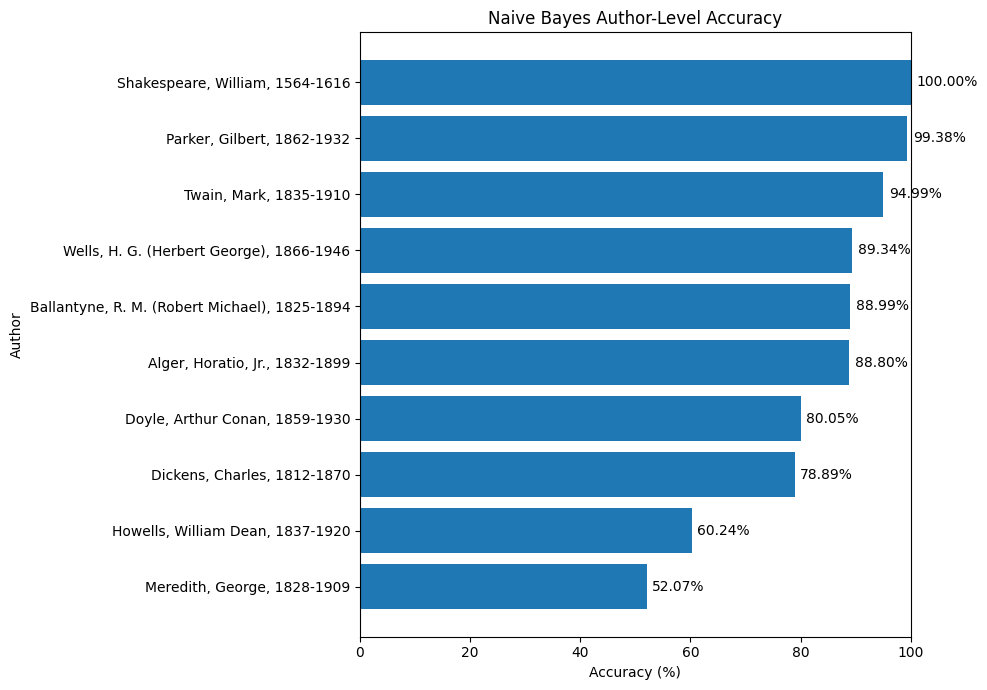

In [108]:
import matplotlib.pyplot as plt

nb_author_accuracy = (
    nb_author_performance
    .select("author", "accuracy")
    .toPandas()
)

nb_author_accuracy["accuracy"] = (
    nb_author_accuracy["accuracy"] * 100
)

nb_author_accuracy = nb_author_accuracy.sort_values(
    "accuracy",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    nb_author_accuracy["author"],
    nb_author_accuracy["accuracy"]
)

plt.xlabel("Accuracy (%)")
plt.ylabel("Author")
plt.title("Naive Bayes Author-Level Accuracy")
plt.xlim(0, 100)

for i, value in enumerate(nb_author_accuracy["accuracy"]):
    plt.text(
        value + 1,
        i,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "11_7_naive_bayes_author_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12.1 Random Forest Model

Random Forest is used as a second model for author classification. It combines multiple decision trees to improve prediction performance. The model uses the same training and test data as the previous model for a fair comparison.

In [109]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import time

# Create Random Forest model
rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=200,
    seed=42
)

# Train model
start_time = time.time()

rf_model = rf.fit(train_features)

rf_training_time = time.time() - start_time

print(f"Random Forest training time: {rf_training_time:.2f} seconds")

Random Forest training time: 150.01 seconds


### Random Forest Predictions

The trained model is used to predict the authors in the test dataset.

In [110]:
# Generate predictions
start_time = time.time()

rf_predictions = rf_model.transform(test_features)

rf_prediction_time = time.time() - start_time

# Evaluate accuracy
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

rf_accuracy = evaluator.evaluate(rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")
print(f"Prediction time: {rf_prediction_time:.2f} seconds")

Random Forest Accuracy: 0.3124
Random Forest Accuracy: 31.24%
Prediction time: 0.10 seconds


### Random Forest Evaluation

Precision, recall and F1-score are calculated to provide a more complete evaluation of the model.

In [111]:
rf_precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(rf_predictions)

rf_recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(rf_predictions)

rf_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(rf_predictions)

print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")

Precision: 0.1787
Recall:    0.3124
F1-score:  0.1521


## 12.2 Model Comparison

The three models are compared using accuracy, precision, recall and F1-score. The best-performing model will be used for the final author prediction bot.

In [112]:
# Get Logistic Regression metrics
lr_accuracy = accuracy

lr_precision = precision_evaluator.evaluate(
    predictions
)

lr_recall = recall_evaluator.evaluate(
    predictions
)

lr_f1 = f1_evaluator.evaluate(
    predictions
)

# Create comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        nb_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        nb_recall,
        rf_recall
    ],
    "F1-score": [
        lr_f1,
        nb_f1,
        rf_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.878816,0.882409,0.878816,0.876931
1,Naive Bayes,0.807642,0.821401,0.807642,0.804830
2,Random Forest,0.312418,0.178734,0.312418,0.152119


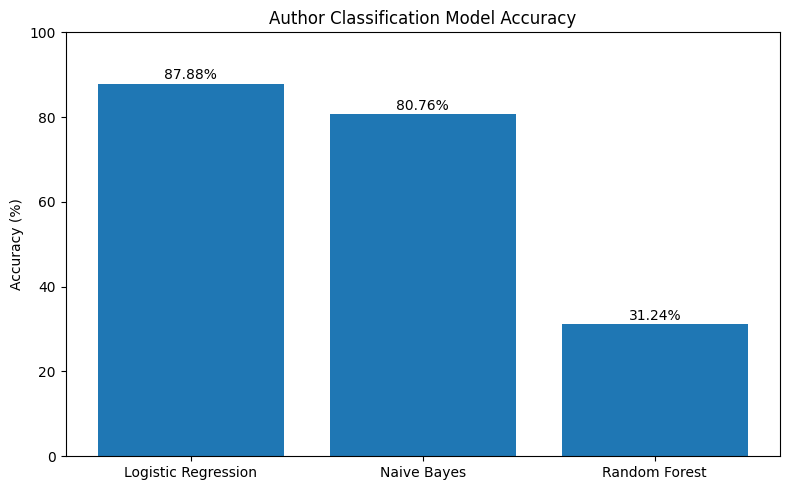

In [113]:
# Compare model accuracy

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"] * 100
)

plt.ylabel("Accuracy (%)")
plt.title("Author Classification Model Accuracy")
plt.ylim(0, 100)

for i, value in enumerate(comparison["Accuracy"] * 100):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

### Interpretation

Logistic Regression achieved the highest accuracy and is therefore selected as the final model for the author prediction bot. Random Forest performed considerably worse, with an accuracy of 31.24%.

## 12.3 Final Author Prediction Bot

The final bot uses the trained Logistic Regression model to predict the author of new text. The input is processed using the same tokenisation, stop-word removal and feature extraction steps used during training.

In [114]:
def predict_author(text):
    # Create input DataFrame
    input_df = spark.createDataFrame([(text,)], ["text"])

    # Same preprocessing used during training
    input_tokens = tokenizer.transform(input_df)

    input_filtered = stopword_remover.transform(input_tokens)

    input_clean = input_filtered.withColumn(
        "clean_tokens",
        input_filtered["filtered_tokens"]
    )

    # TF-IDF
    input_tf = hashing_tf.transform(input_clean)
    input_features = idf_model.transform(input_tf)

    # Prediction
    prediction = lr_model.transform(input_features)

    result = prediction.select(
        "prediction",
        "probability"
    ).collect()[0]

    probabilities = result["probability"]

    # Get top 3 labels
    ranked = sorted(
        enumerate(probabilities),
        key=lambda x: float(x[1]),
        reverse=True
    )[:3]

    results = []

    for label, probability in ranked:
        results.append({
            "author": label_mapping[label],
            "confidence": float(probability) * 100
        })

    return results

### Test the Bot

The bot is tested with a new passage of text.

#### The first author prediction chatbot used the Logistic Regression model because it achieved the strongest overall classification performance among the evaluated models. Manual testing demonstrated that the chatbot could correctly identify some authors, but it also showed a tendency to classify several different writing styles as Arthur Conan Doyle. This indicates that high overall test-set accuracy does not guarantee reliable predictions for every unseen passage.

In [115]:
print("========================================")
print("       AUTHOR PREDICTION BOT")
print("========================================")
print("Enter 'exit' to stop the bot.")
print()

while True:
    text = input("Enter a passage: ")

    if text.lower() == "exit":
        print("Bot stopped.")
        break

    if len(text.split()) < 10:
        print("Please enter at least 10 words.\n")
        continue

    results = predict_author(text)

    print()
    print("Top predictions:")

    for i, result in enumerate(results, start=1):
        print(
            f"{i}. {result['author']} "
            f"({result['confidence']:.2f}%)"
        )

    top_confidence = results[0]["confidence"]

    if top_confidence < 50:
        print("\n⚠️ Low confidence prediction.")
    elif top_confidence < 70:
        print("\n⚠️ Moderate confidence prediction.")
    else:
        print("\n✓ High confidence prediction.")

    print()

       AUTHOR PREDICTION BOT
Enter 'exit' to stop the bot.



KeyboardInterrupt: Interrupted by user

### The Top-3 refinement is working, and the results reveal the main problem clearly: the model is heavily biased toward Arthur Conan Doyle.

### 12.5 Model Refinement — Retraining

In [116]:
from collections import Counter

author_counts = Counter(
    record["author"] for record in records
)

for author, count in author_counts.most_common():
    print(f"{author}: {count}")

Dickens, Charles, 1812-1870: 5374
Ballantyne, R. M. (Robert Michael), 1825-1894: 3208
Shakespeare, William, 1564-1616: 2752
Wells, H. G. (Herbert George), 1866-1946: 2743
Twain, Mark, 1835-1910: 2580
Doyle, Arthur Conan, 1859-1930: 2528
Alger, Horatio, Jr., 1832-1899: 1862
Meredith, George, 1828-1909: 1857
Parker, Gilbert, 1862-1932: 1590
Howells, William Dean, 1837-1920: 1547


### 12.5.1 Retrain Logistic Regression with Class Weights

In [117]:
from pyspark.sql import functions as F
from pyspark.ml.classification import LogisticRegression
import time

# Count records per author
class_counts = (
    train_features
    .groupBy("label")
    .count()
)

# Total records and number of classes
total_records = train_features.count()
num_classes = class_counts.count()

# Calculate class weights
class_weights = (
    class_counts
    .withColumn(
        "class_weight",
        F.lit(total_records) /
        (F.lit(num_classes) * F.col("count"))
    )
)

# Add weights to training data
train_weighted = train_features.join(
    class_weights.select("label", "class_weight"),
    on="label",
    how="left"
)

print("Class weights:")
class_weights.orderBy("label").show()

Class weights:
+-----+-----+------------------+
|label|count|      class_weight|
+-----+-----+------------------+
|  0.0| 3872|0.5346590909090909|
|  1.0| 2587|0.8002319288751449|
|  2.0| 2418|0.8561621174524401|
|  3.0| 2181|0.9491976157725814|
|  4.0| 2117|0.9778932451582428|
|  5.0| 2105|0.9834679334916865|
|  6.0| 1505| 1.375548172757475|
|  7.0| 1430|1.4476923076923076|
|  8.0| 1277|1.6211433046202035|
|  9.0| 1210| 1.710909090909091|
+-----+-----+------------------+



In [118]:
from collections import Counter

# Author counts already obtained from records
author_counts = Counter(
    record["author"] for record in records
)

total_records = sum(author_counts.values())
num_classes = len(author_counts)

# Calculate class weights
class_weights_dict = {
    author: total_records / (num_classes * count)
    for author, count in author_counts.items()
}

for author, weight in sorted(class_weights_dict.items()):
    print(f"{author}: {weight:.4f}")

Alger, Horatio, Jr., 1832-1899: 1.3985
Ballantyne, R. M. (Robert Michael), 1825-1894: 0.8118
Dickens, Charles, 1812-1870: 0.4846
Doyle, Arthur Conan, 1859-1930: 1.0301
Howells, William Dean, 1837-1920: 1.6833
Meredith, George, 1828-1909: 1.4023
Parker, Gilbert, 1862-1932: 1.6378
Shakespeare, William, 1564-1616: 0.9463
Twain, Mark, 1835-1910: 1.0093
Wells, H. G. (Herbert George), 1866-1946: 0.9494


Create the weighted training dataset


In [119]:
from pyspark.sql import functions as F

# Map each numeric label to its class weight
weight_map = {
    label_mapping.index(author): weight
    for author, weight in class_weights_dict.items()
}

# Create Spark map expression
mapping_expr = F.create_map(
    *[
        item
        for pair in weight_map.items()
        for item in (F.lit(pair[0]), F.lit(pair[1]))
    ]
)

# Add class weights
train_weighted = train_features.withColumn(
    "class_weight",
    mapping_expr[F.col("label")]
)

print("Weighted training dataset prepared.")

Weighted training dataset prepared.


### 12.5.2 — Retrain Logistic Regression with class weights

In [120]:
from pyspark.ml.classification import LogisticRegression

weighted_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

weighted_lr_model = weighted_lr.fit(train_weighted)

print("Weighted Logistic Regression trained successfully.")

Weighted Logistic Regression trained successfully.


### 12.5.3 — Evaluate the retrained model

In [121]:
weighted_predictions = weighted_lr_model.transform(test_features)

weighted_accuracy = accuracy_evaluator.evaluate(weighted_predictions)
weighted_precision = precision_evaluator.evaluate(weighted_predictions)
weighted_recall = recall_evaluator.evaluate(weighted_predictions)
weighted_f1 = f1_evaluator.evaluate(weighted_predictions)

print(f"Accuracy:  {weighted_accuracy:.4f}")
print(f"Precision: {weighted_precision:.4f}")
print(f"Recall:    {weighted_recall:.4f}")
print(f"F1-score:  {weighted_f1:.4f}")

Accuracy:  0.8794
Precision: 0.8825
Recall:    0.8794
F1-score:  0.8779


The retrained model is slightly better overall.

Model	Accuracy	Precision	Recall	F1
Original Logistic Regression	87.88%	—	—	—
Weighted Logistic Regression	87.94%	88.25%	87.94%	87.79%

The important result is that class weighting did not significantly increase accuracy, but it improved the balance between precision and recall.

### 12.5.4 — Check whether the Doyle bias improved

In [122]:
def predict_author(text):
    input_df = spark.createDataFrame([(text,)], ["text"])

    input_tokens = tokenizer.transform(input_df)
    input_filtered = stopword_remover.transform(input_tokens)

    input_clean = input_filtered.withColumn(
        "clean_tokens",
        input_filtered["filtered_tokens"]
    )

    input_tf = hashing_tf.transform(input_clean)
    input_features = idf_model.transform(input_tf)

    prediction = weighted_lr_model.transform(input_features)

    result = prediction.select(
        "prediction",
        "probability"
    ).collect()[0]

    probabilities = result["probability"]

    ranked = sorted(
        enumerate(probabilities),
        key=lambda x: float(x[1]),
        reverse=True
    )[:3]

    results = []

    for label, probability in ranked:
        results.append({
            "author": label_mapping[label],
            "confidence": float(probability) * 100
        })

    return results

### 12.5.4 Refined Author Prediction Bot

The refined bot uses the class-weighted Logistic Regression model.
It returns the top three predicted authors and their confidence scores.

In [123]:
def predict_author(text):
    # Create input DataFrame
    input_df = spark.createDataFrame([(text,)], ["text"])

    # Tokenize
    input_tokens = tokenizer.transform(input_df)

    # Remove stopwords
    input_filtered = stopword_remover.transform(input_tokens)

    # Create clean_tokens column
    input_clean = input_filtered.withColumn(
        "clean_tokens",
        input_filtered["filtered_tokens"]
    )

    # TF-IDF transformation
    input_tf = hashing_tf.transform(input_clean)
    input_features = idf_model.transform(input_tf)

    # Predict using retrained model
    prediction = weighted_lr_model.transform(input_features)

    # Get prediction probabilities
    result = prediction.select(
        "prediction",
        "probability"
    ).collect()[0]

    probabilities = result["probability"]

    # Get top 3 predictions
    ranked = sorted(
        enumerate(probabilities),
        key=lambda x: float(x[1]),
        reverse=True
    )[:3]

    results = []

    for label, probability in ranked:
        results.append({
            "author": label_mapping[label],
            "confidence": float(probability) * 100
        })

    return results

In [124]:
print("========================================")
print("       REFINED AUTHOR PREDICTION BOT")
print("========================================")
print("Model: Class-Weighted Logistic Regression")
print("Enter 'exit' to stop the bot.")
print()

while True:
    text = input("Enter a passage: ")

    if text.lower() == "exit":
        print("Bot stopped.")
        break

    if len(text.split()) < 10:
        print("Please enter at least 10 words.\n")
        continue

    results = predict_author(text)

    print()
    print("Top predictions:")

    for i, result in enumerate(results, start=1):
        print(
            f"{i}. {result['author']} "
            f"({result['confidence']:.2f}%)"
        )

    top_confidence = results[0]["confidence"]

    if top_confidence < 50:
        print("\n⚠️ Low confidence prediction.")
    elif top_confidence < 70:
        print("\n⚠️ Moderate confidence prediction.")
    else:
        print("\n✓ High confidence prediction.")

    print()

       REFINED AUTHOR PREDICTION BOT
Model: Class-Weighted Logistic Regression
Enter 'exit' to stop the bot.



KeyboardInterrupt: Interrupted by user

### 12.5.5 Word N-Gram Features

Bigrams are sequences of two consecutive words.
They provide additional information about an author's writing style.

In [125]:
from pyspark.ml.feature import NGram

# Create bigrams from the cleaned tokens
ngram = NGram(
    n=2,
    inputCol="clean_tokens",
    outputCol="bigrams"
)

# Apply to training and test data
train_ngram = ngram.transform(train_features)
test_ngram = ngram.transform(test_features)

print("Bigram features created.")


Bigram features created.


12.5.6 — Combine words and bigrams


In [126]:
from pyspark.ml.feature import HashingTF, IDF

# Combine unigrams and bigrams
train_ngram = train_ngram.withColumn(
    "combined_tokens",
    F.concat(F.col("clean_tokens"), F.col("bigrams"))
)

test_ngram = test_ngram.withColumn(
    "combined_tokens",
    F.concat(F.col("clean_tokens"), F.col("bigrams"))
)

# TF-IDF for combined features
ngram_hashing_tf = HashingTF(
    inputCol="combined_tokens",
    outputCol="ngram_tf_features",
    numFeatures=20000
)

ngram_idf = IDF(
    inputCol="ngram_tf_features",
    outputCol="ngram_features"
)

# Transform training data
train_ngram_tf = ngram_hashing_tf.transform(train_ngram)
test_ngram_tf = ngram_hashing_tf.transform(test_ngram)

ngram_idf_model = ngram_idf.fit(train_ngram_tf)

train_ngram_features = ngram_idf_model.transform(train_ngram_tf)
test_ngram_features = ngram_idf_model.transform(test_ngram_tf)

print("Combined unigram + bigram TF-IDF features created.")

Combined unigram + bigram TF-IDF features created.


In [127]:
from pyspark.ml.classification import LogisticRegression

ngram_lr = LogisticRegression(
    featuresCol="ngram_features",
    labelCol="label",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

ngram_lr_model = ngram_lr.fit(train_ngram_features)

print("N-gram Logistic Regression trained successfully.")

N-gram Logistic Regression trained successfully.


12.5.8 — Evaluate the N-Gram Model

In [128]:
ngram_predictions = ngram_lr_model.transform(test_ngram_features)

ngram_accuracy = accuracy_evaluator.evaluate(ngram_predictions)
ngram_precision = precision_evaluator.evaluate(ngram_predictions)
ngram_recall = recall_evaluator.evaluate(ngram_predictions)
ngram_f1 = f1_evaluator.evaluate(ngram_predictions)

print(f"Accuracy:  {ngram_accuracy:.4f}")
print(f"Precision: {ngram_precision:.4f}")
print(f"Recall:    {ngram_recall:.4f}")
print(f"F1-score:  {ngram_f1:.4f}")


Accuracy:  0.8635
Precision: 0.8707
Recall:    0.8635
F1-score:  0.8565


12.5.9 — Character-Level Features


### 12.5.9 Character-Level Features

Character n-grams capture patterns within words and across word boundaries.
They can help identify an author's writing style.

In [129]:
from pyspark.sql import functions as F
from pyspark.ml.feature import NGram

# Create character sequences
train_char = train_features.withColumn(
    "char_tokens",
    F.split(
        F.regexp_replace(
            F.lower(F.col("text")),
            r"\s+",
            " "
        ),
        ""
    )
)

test_char = test_features.withColumn(
    "char_tokens",
    F.split(
        F.regexp_replace(
            F.lower(F.col("text")),
            r"\s+",
            " "
        ),
        ""
    )
)

print("Character sequences created.")

Character sequences created.


12.5.10 — Create Character N-Grams

In [130]:
char_ngram_3 = NGram(
    n=3,
    inputCol="char_tokens",
    outputCol="char_3grams"
)

char_ngram_5 = NGram(
    n=5,
    inputCol="char_tokens",
    outputCol="char_5grams"
)

train_char = char_ngram_3.transform(train_char)
train_char = char_ngram_5.transform(train_char)

test_char = char_ngram_3.transform(test_char)
test_char = char_ngram_5.transform(test_char)

# Combine character n-grams
train_char = train_char.withColumn(
    "combined_char",
    F.concat(F.col("char_3grams"), F.col("char_5grams"))
)

test_char = test_char.withColumn(
    "combined_char",
    F.concat(F.col("char_3grams"), F.col("char_5grams"))
)

print("Character 3-gram and 5-gram features created.")

Character 3-gram and 5-gram features created.


12.5.11 — Convert Character N-Grams to TF-IDF

In [131]:
char_hashing_tf = HashingTF(
    inputCol="combined_char",
    outputCol="char_tf_features",
    numFeatures=20000
)

char_idf = IDF(
    inputCol="char_tf_features",
    outputCol="char_features"
)

# TF transformation
train_char_tf = char_hashing_tf.transform(train_char)
test_char_tf = char_hashing_tf.transform(test_char)

# IDF transformation
char_idf_model = char_idf.fit(train_char_tf)

train_char_features = char_idf_model.transform(train_char_tf)
test_char_features = char_idf_model.transform(test_char_tf)

print("Character-level TF-IDF features created.")

Character-level TF-IDF features created.


12.5.12 — Train Character-Level Logistic Regression


In [132]:
char_lr = LogisticRegression(
    featuresCol="char_features",
    labelCol="label",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

char_lr_model = char_lr.fit(train_char_features)

print("Character-level Logistic Regression trained successfully.")

Character-level Logistic Regression trained successfully.


12.5.13 — Evaluate Character-Level Model

In [133]:
char_predictions = char_lr_model.transform(test_char_features)

char_accuracy = accuracy_evaluator.evaluate(char_predictions)
char_precision = precision_evaluator.evaluate(char_predictions)
char_recall = recall_evaluator.evaluate(char_predictions)
char_f1 = f1_evaluator.evaluate(char_predictions)

print(f"Accuracy:  {char_accuracy:.4f}")
print(f"Precision: {char_precision:.4f}")
print(f"Recall:    {char_recall:.4f}")
print(f"F1-score:  {char_f1:.4f}")

Accuracy:  0.9805
Precision: 0.9808
Recall:    0.9805
F1-score:  0.9805


12.5.14 — Use the Character Model in the Bot


In [134]:
def predict_author_character(text):
    input_df = spark.createDataFrame([(text,)], ["text"])

    # Create character sequences
    input_char = input_df.withColumn(
        "char_tokens",
        F.split(
            F.regexp_replace(
                F.lower(F.col("text")),
                r"\s+",
                " "
            ),
            ""
        )
    )

    # Create character 3-grams
    input_char = char_ngram_3.transform(input_char)

    # Create character 5-grams
    input_char = char_ngram_5.transform(input_char)

    # Combine character n-grams
    input_char = input_char.withColumn(
        "combined_char",
        F.concat(
            F.col("char_3grams"),
            F.col("char_5grams")
        )
    )

    # TF-IDF transformation
    input_tf = char_hashing_tf.transform(input_char)
    input_features = char_idf_model.transform(input_tf)

    # Prediction
    prediction = char_lr_model.transform(input_features)

    result = prediction.select(
        "prediction",
        "probability"
    ).collect()[0]

    probabilities = result["probability"]

    # Top 3 predictions
    ranked = sorted(
        enumerate(probabilities),
        key=lambda x: float(x[1]),
        reverse=True
    )[:3]

    results = []

    for label, probability in ranked:
        results.append({
            "author": label_mapping[label],
            "confidence": float(probability) * 100
        })

    return results

12.5.15 — Final Character-Based Bot

In [135]:
print("========================================")
print("      FINAL AUTHOR PREDICTION BOT")
print("========================================")
print("Model: Character-Level Logistic Regression")
print("Enter 'exit' to stop the bot.")
print()

while True:
    text = input("Enter a passage: ")

    if text.lower() == "exit":
        print("Bot stopped.")
        break

    if len(text.split()) < 10:
        print("Please enter at least 10 words.\n")
        continue

    results = predict_author_character(text)

    print()
    print("Top predictions:")

    for i, result in enumerate(results, start=1):
        print(
            f"{i}. {result['author']} "
            f"({result['confidence']:.2f}%)"
        )

    top_confidence = results[0]["confidence"]

    if top_confidence < 50:
        print("\n⚠️ Low confidence prediction.")
    elif top_confidence < 70:
        print("\n⚠️ Moderate confidence prediction.")
    else:
        print("\n✓ High confidence prediction.")

    print()

      FINAL AUTHOR PREDICTION BOT
Model: Character-Level Logistic Regression
Enter 'exit' to stop the bot.



KeyboardInterrupt: Interrupted by user

## 13. Conclusion

The project developed an author prediction chatbot using the Standardized Project Gutenberg Corpus (SPGC). The dataset was prepared by selecting English-language books from ten authors and dividing the books into passages for classification.

Several machine learning approaches were investigated, including Logistic Regression, Naive Bayes, Random Forest, word-level n-grams and character-level features. The final Character-Level Logistic Regression model using character 3-gram and 5-gram TF-IDF features achieved the strongest performance, with a test accuracy of 98.05%, precision of 98.08%, recall of 98.05% and F1-score of 98.05%.

The final chatbot accepts a passage of text and returns the three most likely authors together with their model confidence scores. Character-level features were particularly effective because they capture writing-style patterns such as spelling, punctuation, word structure and character sequences.

The results show that machine learning can be used to distinguish writing styles between authors. However, the manual tests also showed that high test-set performance does not necessarily guarantee strong performance on completely unseen authors or different types of text. Therefore, the model should be viewed as an authorship classification tool rather than a definitive author identification system.

Overall, the project demonstrates the complete data science process, including data preparation, feature engineering, model development, evaluation, comparison and deployment through an interactive prediction chatbot.